Z shape: (18, 101, 9)
cavity_frequency shape: (18, 101)
stark_ampx shape: (18, 9)
current [mA]: [0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5]
0.80 mA: rejected, no real peak
0.90 mA: rejected, no real peak
1.00 mA: rejected, no real peak


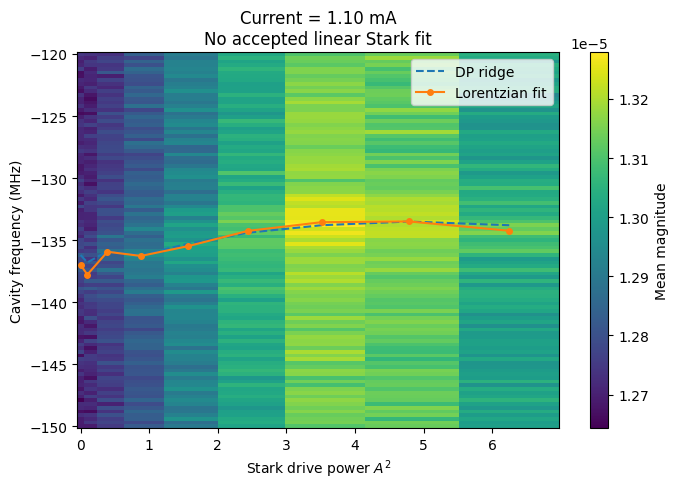

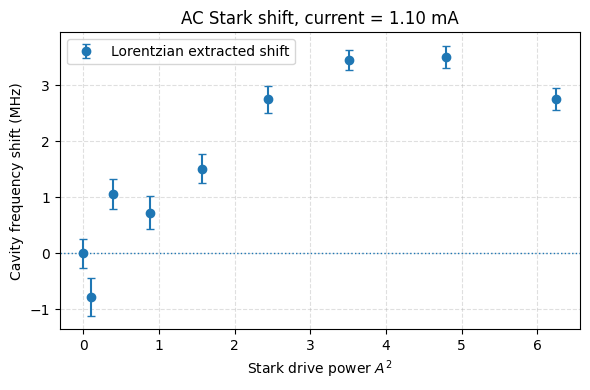

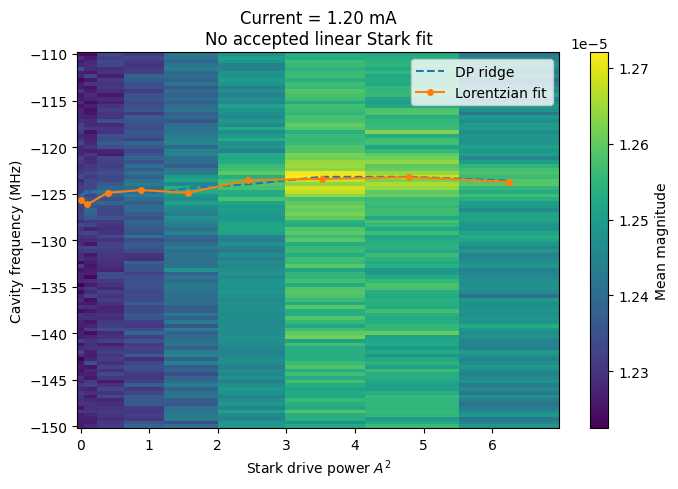

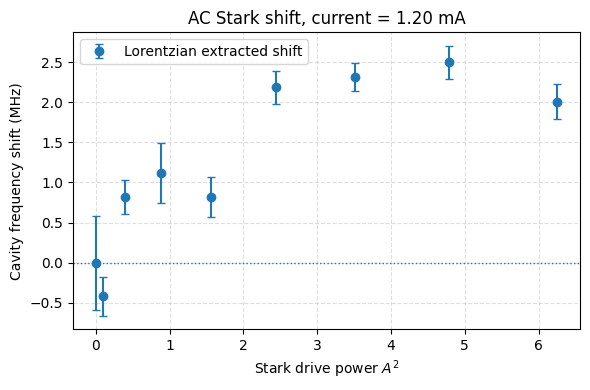

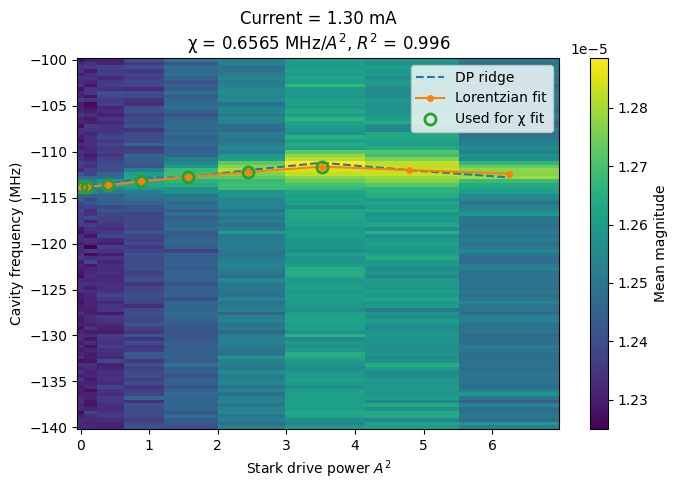

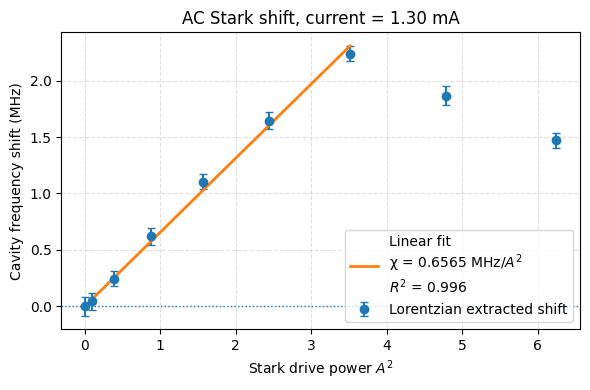

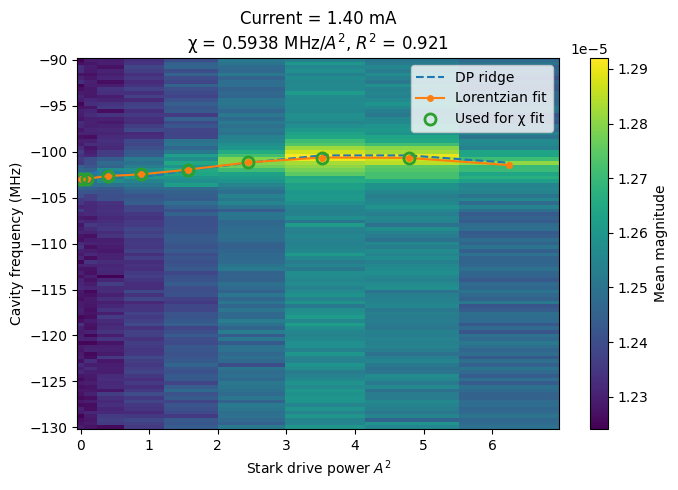

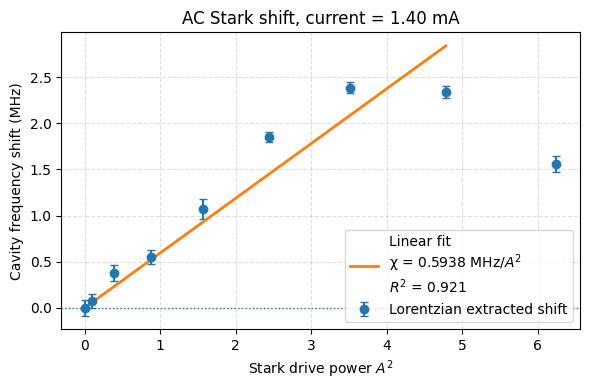

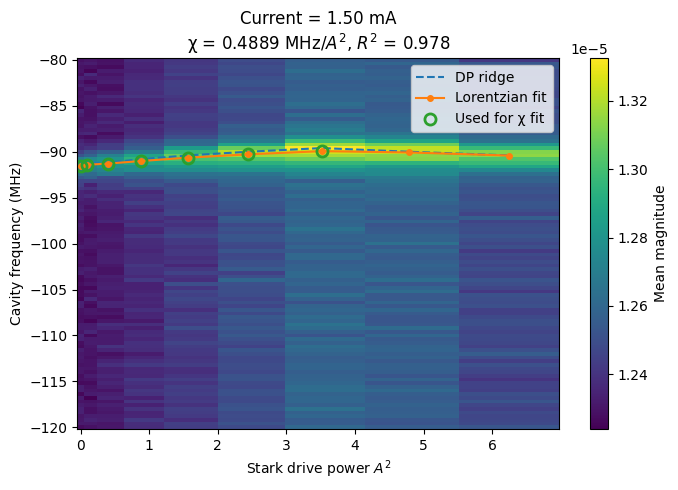

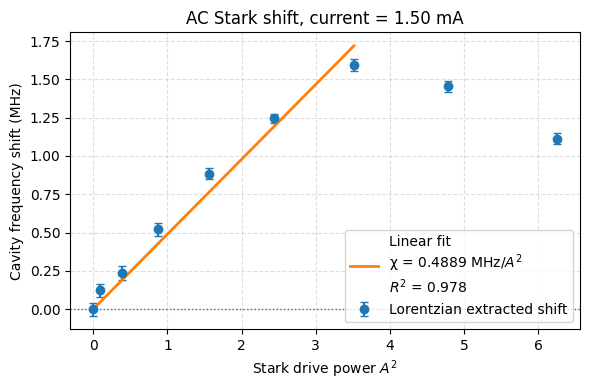

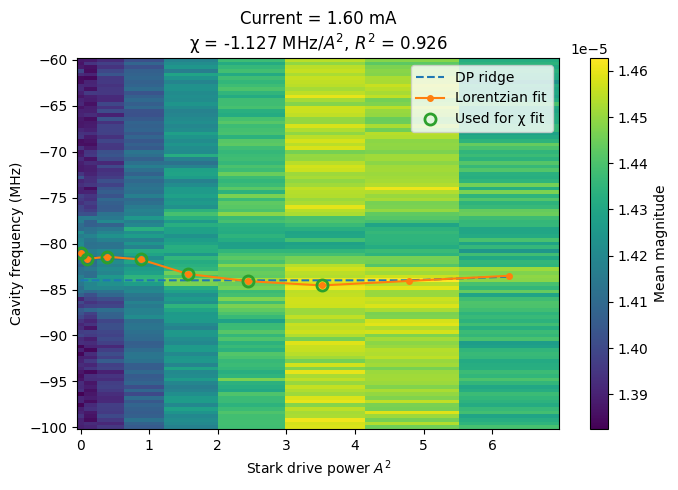

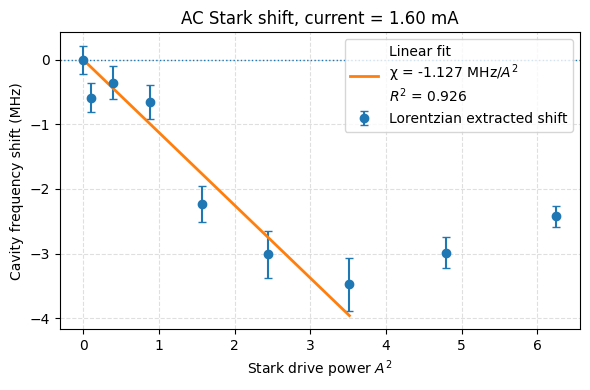

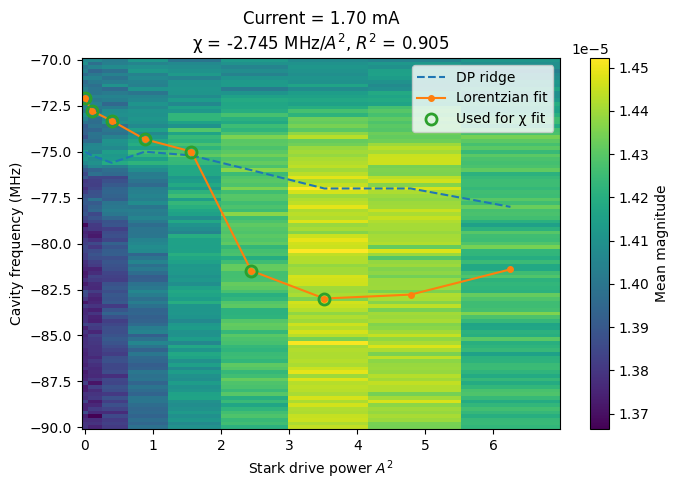

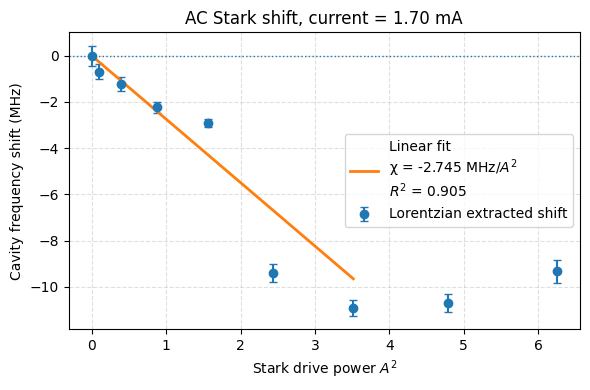

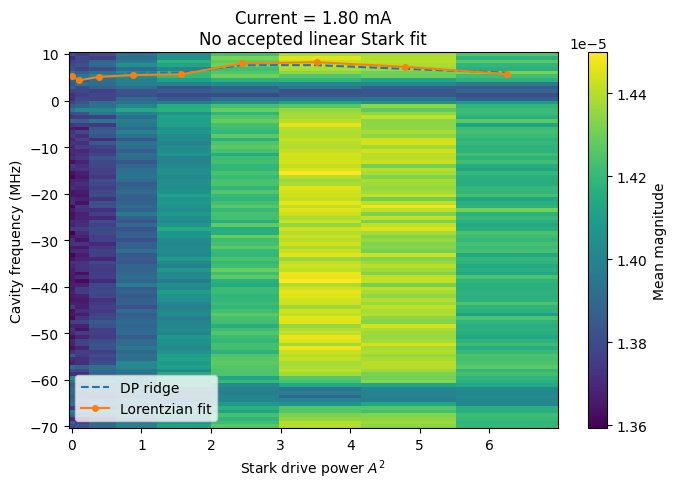

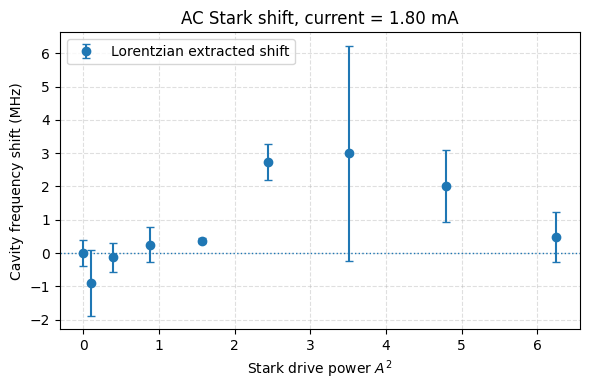

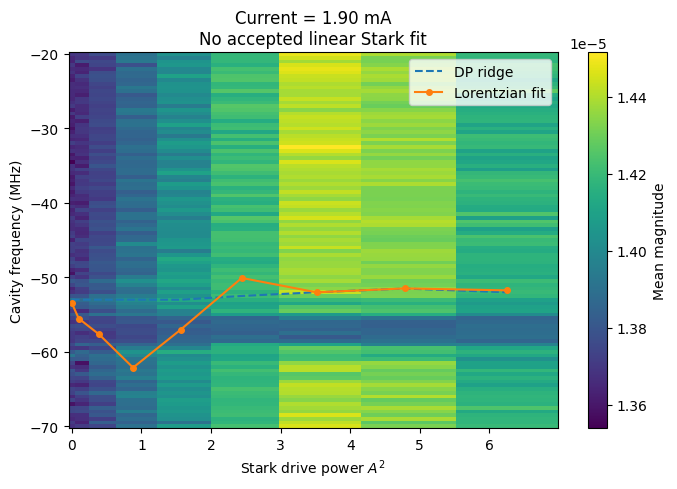

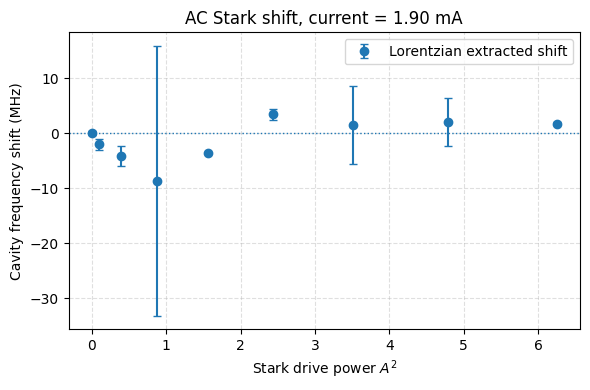

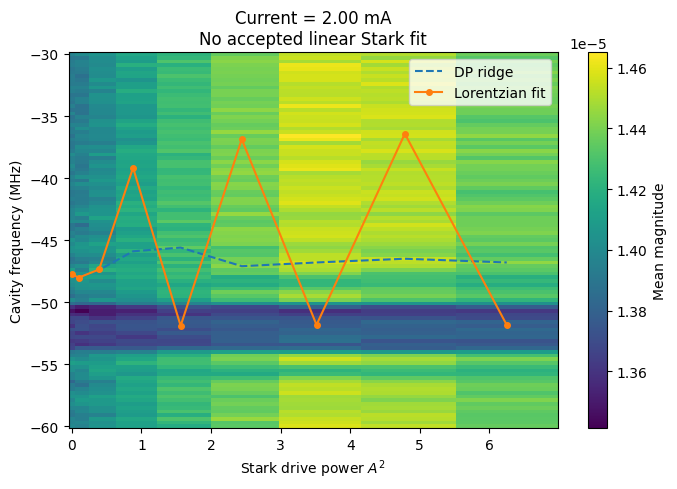

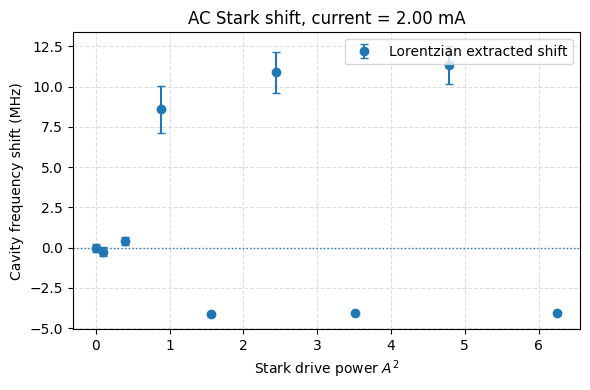

2.10 mA: rejected, no real peak


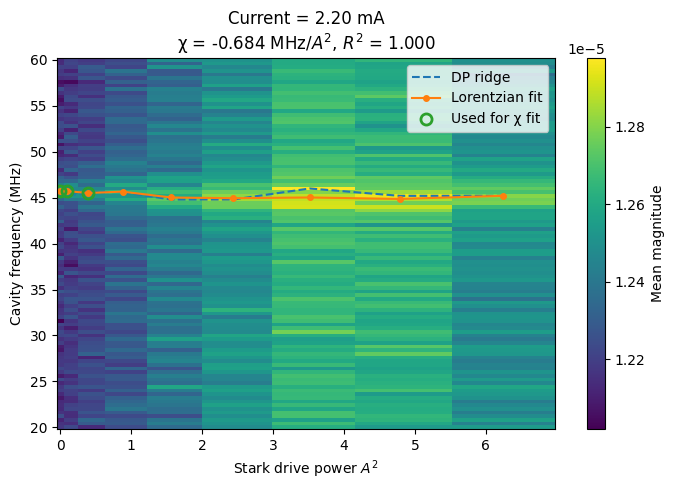

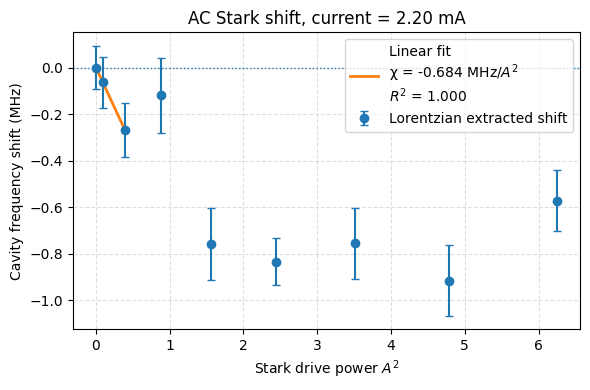

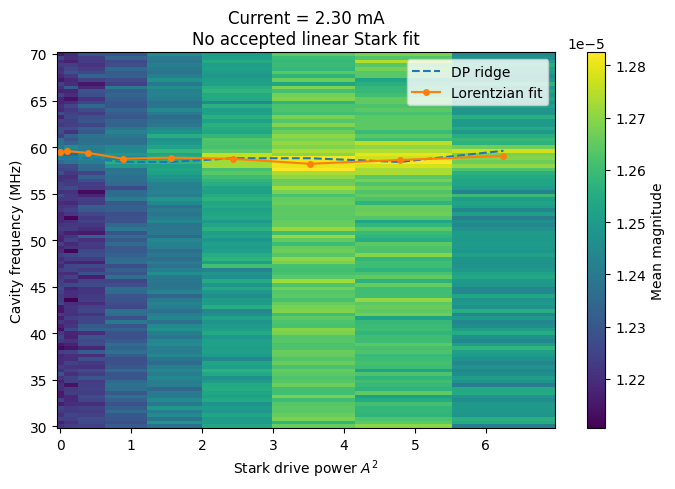

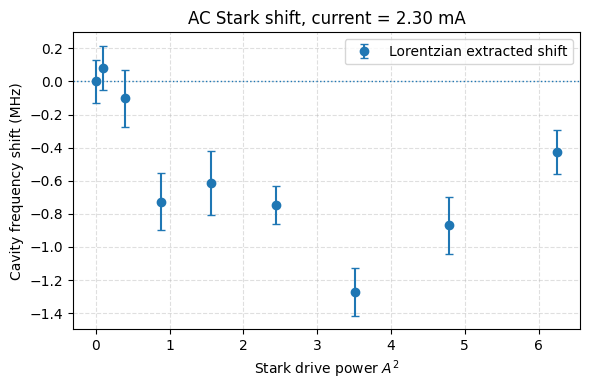

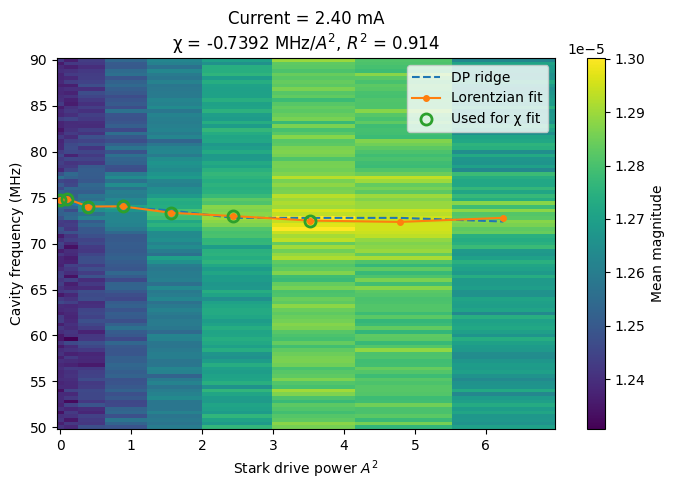

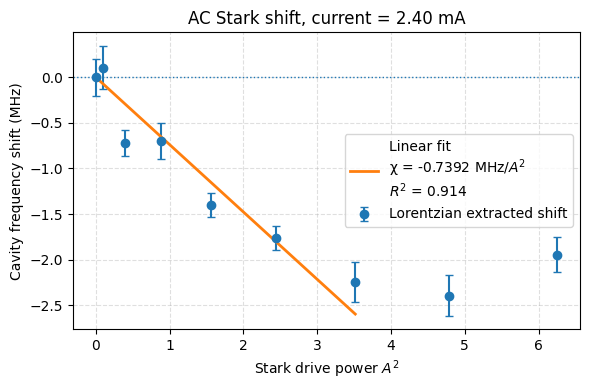

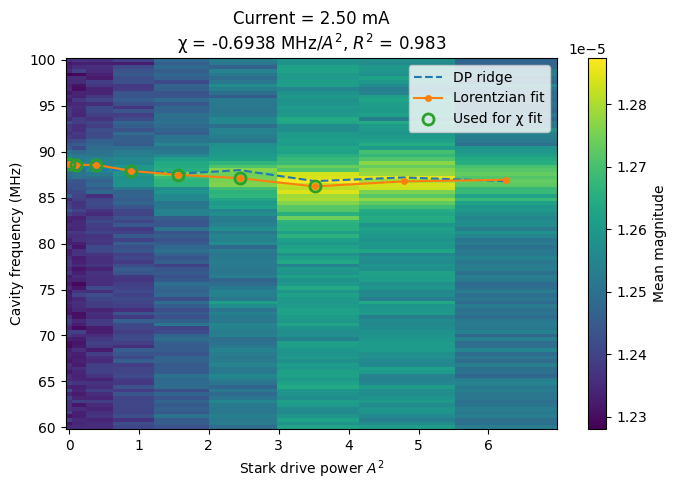

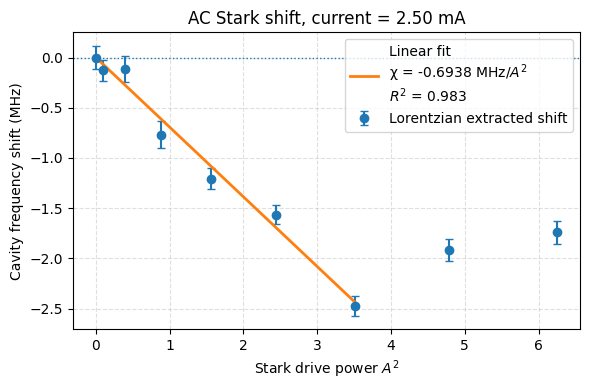

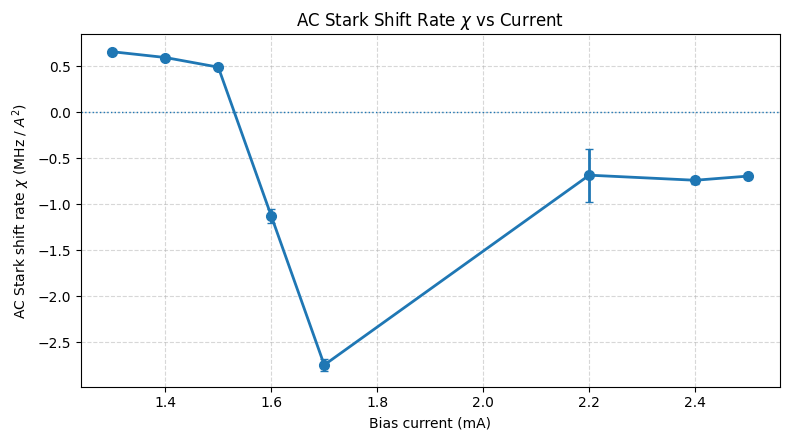

In [15]:
"""
AC Stark shift (chi) extraction vs. flux bias, plotted in flux-quanta units.

Pipeline per flux point:
  1. DP ridge-track the cavity resonance across the whole power sweep at once
     (globally consistent, smooth f0(power) path -> robust against a single
     bad/noisy frame derailing the fit chain).
  2. Use the DP path as the f0 seed for a per-power-step bounded Lorentzian
     fit (gamma/amp/offset estimated fresh from local data each step).
  3. shift(power) = f0_fit(power) - f0_fit(zero power).
  4. Find the largest contiguous low-power range where shift(power) is linear
     in power (R^2 >= threshold); fit chi = shift/power through the origin
     (weighted by each point's fit uncertainty).
  5. Convert flux (bias current, mA) -> flux quanta Phi/Phi0 and plot.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---------------------------------------------------------------- settings
SNR_MIN = 3.5                # minimum peak SNR to attempt a flux point
R2_MIN = 0.90                 # minimum R^2 to accept the linear (chi) regime
MAX_SHIFT_MHZ = 50.0          # discard points beyond this as fit artifacts
MIN_LINEAR_POINTS = 3         # need at least this many points to trust chi
DP_LAMBDA = 0.4               # DP smoothness penalty weight (see dp_ridge_track)
I_PERIOD_MA = 26.857          # flux period, mA
I0_MA = -10.000               # current at Phi/Phi0 = 0, mA


def lorentzian(f, f0, gamma, amp, offset):
    return offset + amp * (gamma**2 / ((f - f0) ** 2 + gamma**2))


def robust_snr(z):
    """Peak-to-peak signal over a median-absolute-deviation noise estimate."""
    med = np.median(z)
    mad = np.median(np.abs(z - med)) * 1.4826  # -> sigma-equivalent
    if mad == 0:
        return np.inf
    return (np.max(z) - np.min(z)) / mad


def dp_ridge_track(f_axis, Z_slice, lam=DP_LAMBDA):
    """
    Globally-optimal smooth ridge (resonance-frequency path) across a
    frequency x power slice, via dynamic programming (Viterbi-style).

    Cost at each (frequency, power) node is based on a per-column z-score
    of the signal (so different power steps with different baseline/amp
    are comparable). Transition cost between adjacent power steps penalizes
    large frequency jumps, encoding the physical prior that the resonance
    moves smoothly with power.

    Parameters
    ----------
    f_axis : (n_freq,) array, frequency axis in MHz
    Z_slice : (n_freq, n_power) array, signal for this flux point
    lam : transition penalty weight (larger = smoother/stiffer path)

    Returns
    -------
    f0_path : (n_power,) array, tracked resonance frequency at each power
    """
    n_freq, n_power = Z_slice.shape

    med = np.median(Z_slice, axis=0, keepdims=True)
    mad = np.median(np.abs(Z_slice - med), axis=0, keepdims=True) * 1.4826
    mad[mad == 0] = 1.0
    zscore = (Z_slice - med) / mad
    cost = -zscore  # lower cost = stronger signal = more likely the peak

    D = np.empty((n_freq, n_power))
    ptr = np.empty((n_freq, n_power), dtype=int)
    D[:, 0] = cost[:, 0]

    # (n_freq, n_freq) matrix of squared frequency differences, reused every step
    f_diff2 = (f_axis[:, None] - f_axis[None, :]) ** 2

    for j in range(1, n_power):
        # trans[i, k] = cost of having come from freq index k at step j-1
        # to freq index i at step j
        trans = D[None, :, j - 1] + lam * f_diff2
        ptr[:, j] = np.argmin(trans, axis=1)
        D[:, j] = cost[:, j] + trans[np.arange(n_freq), ptr[:, j]]

    path_idx = np.empty(n_power, dtype=int)
    path_idx[-1] = np.argmin(D[:, -1])
    for j in range(n_power - 1, 0, -1):
        path_idx[j - 1] = ptr[path_idx[j], j]

    return f_axis[path_idx]


def fit_lorentzian(f_axis, z, p0):
    """Bounded Lorentzian fit; returns (popt, pcov) or None on failure."""
    f_lo, f_hi = f_axis.min(), f_axis.max()
    span = f_hi - f_lo
    lower = [f_lo, 1e-3, -np.inf, -np.inf]
    upper = [f_hi, span, np.inf, np.inf]
    p0 = np.clip(p0, [b + 1e-9 for b in lower], [b - 1e-9 for b in upper])
    try:
        popt, pcov = curve_fit(
            lorentzian, f_axis, z, p0=p0,
            bounds=(lower, upper), maxfev=4000,
        )
        return popt, pcov
    except Exception:
        return None

def has_real_peak(z, min_width=2, z_thresh=2.0):
    """
    Reject flux points whose "resonance" is really just a single noisy bin.

    robust_snr() only measures peak-height / MAD, which a lone noise spike
    can satisfy just as easily as a genuine Lorentzian dip/peak. A real
    cavity line is several bins wide (set by its linewidth); pure noise is
    not. This checks that the region around the max z-score is at least
    `min_width` contiguous bins above half-max (and above z_thresh/2), and
    rejects single-bin spikes.
    """
    med = np.median(z)
    mad = np.median(np.abs(z - med)) * 1.4826
    if mad == 0:
        return False
    zscore = (z - med) / mad
    i = np.argmax(zscore)
    half = zscore[i] / 2
    above = zscore > max(half, z_thresh / 2)
    lo = i
    while lo > 0 and above[lo - 1]:
        lo -= 1
    hi = i
    while hi < len(above) - 1 and above[hi + 1]:
        hi += 1
    return (hi - lo + 1) >= min_width


# def main():
#     data = np.load("CavitySpec_stark_shift_2D_current_0.8mA_to_2.5mA.npz")
#     Z = data["Z"]
#     cav_freq = data["cavity_frequency"]
#     stark_ampx = data["stark_ampx"]
#     flux = data["flux"]#*1e3  # bias current, mA

#     dynamic_summary = []

#     for idx in range(len(flux)):
#         f_axis = cav_freq[idx] / 1e6           # Hz -> MHz
#         stark_amps = stark_ampx[idx]
#         power = stark_amps ** 2
#         z0 = Z[idx, :, 0]

#         # before
#         if robust_snr(z0) < SNR_MIN:
#             continue

#         # after
#         if robust_snr(z0) < SNR_MIN or not has_real_peak(z0):
#             continue

#         # --- DP ridge track across the whole power sweep for this flux idx
#         f0_dp = dp_ridge_track(f_axis, Z[idx], lam=DP_LAMBDA)

#         # --- per-power-step bounded Lorentzian fit, seeded from the DP path
#         shifts, shift_errs = [], []
#         gamma_guess = 1.5  # MHz, only carried across steps; position comes from DP
#         f0_fits = np.full(len(stark_amps), np.nan)
#         for j in range(len(stark_amps)):
#             zj = Z[idx, :, j]
#             amp_guess = np.max(zj) - np.min(zj)
#             offset_guess = np.min(zj)
#             p0 = [f0_dp[j], gamma_guess, amp_guess, offset_guess]
#             fit_j = fit_lorentzian(f_axis, zj, p0)
#             if fit_j is None:
#                 break
#             popt, pcov = fit_j
#             perr = np.sqrt(np.diag(pcov))
#             f0_fits[j] = popt[0]
#             gamma_guess = max(popt[1], 1e-3)
#             if j == 0:
#                 f_ref = popt[0]
#             shifts.append(popt[0] - f_ref)
#             shift_errs.append(perr[0])
#         shifts = np.array(shifts)
#         shift_errs = np.array(shift_errs)

#         if len(shifts) < MIN_LINEAR_POINTS:
#             continue

#         # --- dynamic search for the largest contiguous linear (low-power) range
#         best_k, best_chi, best_chi_err, best_r2 = 0, np.nan, np.nan, -1.0
#         for k in range(MIN_LINEAR_POINTS, len(shifts) + 1):
#             p_sub = power[:k]
#             s_sub = shifts[:k]
#             if np.any(np.abs(s_sub) > MAX_SHIFT_MHZ):
#                 break  # beyond this, treat as fit artifact / bifurcation onset

#             e_sub = shift_errs[:k]
#             w = 1.0 / np.clip(e_sub, 1e-6, None) ** 2
#             chi = np.sum(w * p_sub * s_sub) / np.sum(w * p_sub ** 2)
#             chi_err = 1.0 / np.sqrt(np.sum(w * p_sub ** 2))

#             y_pred = chi * p_sub
#             ss_res = np.sum((s_sub - y_pred) ** 2)
#             ss_tot = np.sum((s_sub - np.mean(s_sub)) ** 2)
#             r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0

#             if r2 >= R2_MIN and k >= best_k:
#                 best_k, best_chi, best_chi_err, best_r2 = k, chi, chi_err, r2

#         if best_k >= MIN_LINEAR_POINTS:
#             dynamic_summary.append({
#                 "flux_mA": flux[idx],
#                 "chi": best_chi,
#                 "chi_err": best_chi_err,
#                 "n_points": best_k,
#                 "r2": best_r2,
#             })

#     dynamic_summary.sort(key=lambda x: x["flux_mA"])
#     if not dynamic_summary:
#         raise RuntimeError("No flux points passed the SNR/linearity criteria.")

#     flux_mA = np.array([r["flux_mA"] for r in dynamic_summary])
#     chis = np.array([r["chi"] for r in dynamic_summary])
#     chi_errs = np.array([r["chi_err"] for r in dynamic_summary])

#     # ---- convert bias current -> flux quanta -----------------------------
#     phi = (flux_mA - I0_MA) / I_PERIOD_MA

#     # ---------------------------------------------------------------- plot
#     fig, ax = plt.subplots(figsize=(8, 4.5))
#     color_chi = "#d62728"
#     ax.errorbar(
#         phi, chis, yerr=chi_errs, fmt="o-", color=color_chi,
#         linewidth=2, markersize=7, capsize=3,
#     )
#     ax.set_xlabel(r"Flux Bias $\Phi/\Phi_0$", fontsize=11, fontweight="bold")
#     ax.set_ylabel(r"ac Stark Shift Rate $\chi$ (MHz / $A^2$)", fontsize=11, fontweight="bold")
#     ax.axhline(0, color="gray", linestyle=":", linewidth=1, alpha=0.7)
#     ax.grid(True, linestyle="--", alpha=0.5)
#     ax.set_title(r"ac Stark Shift Rate ($\chi$) vs. Flux Bias", fontsize=12, pad=12)
#     plt.tight_layout()
#     plt.savefig("chi_vs_flux_quanta.png", dpi=300)
#     plt.show()

#     return dynamic_summary
def main():

    data_path = (
        r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot"
        r"\data_plot_data"
        r"\CavitySpec_stark_shift_2D_current_0.8mA_to_2.5mA.npz"
    )

    data = np.load(data_path)

    Z = data["Z"]
    cav_freq = data["cavity_frequency"]
    stark_ampx = data["stark_ampx"]

    # NEW NPZ key
    current_mA = data["current_mA"]

    print("Z shape:", Z.shape)
    print("cavity_frequency shape:", cav_freq.shape)
    print("stark_ampx shape:", stark_ampx.shape)
    print("current [mA]:", current_mA)

    dynamic_summary = []


    # ==========================================================
    # LOOP OVER CURRENT
    # ==========================================================

    for idx in range(len(current_mA)):

        current = current_mA[idx]

        f_axis = cav_freq[idx] / 1e6       # Hz -> MHz
        stark_amps = stark_ampx[idx]
        power = stark_amps ** 2

        Z_slice = Z[idx]

        z0 = Z_slice[:, 0]


        # ======================================================
        # CHECK DATA QUALITY
        # ======================================================

        if robust_snr(z0) < SNR_MIN:
            print(
                f"{current:.2f} mA: rejected, "
                f"SNR = {robust_snr(z0):.2f}"
            )
            continue

        if not has_real_peak(z0):
            print(
                f"{current:.2f} mA: rejected, "
                "no real peak"
            )
            continue


        # ======================================================
        # DP RIDGE TRACK
        # ======================================================

        f0_dp = dp_ridge_track(
            f_axis,
            Z_slice,
            lam=DP_LAMBDA,
        )


        # ======================================================
        # LORENTZIAN FIT AT EACH STARK POWER
        # ======================================================

        f0_fits = np.full(
            len(stark_amps),
            np.nan,
        )

        f0_errs = np.full(
            len(stark_amps),
            np.nan,
        )

        gamma_fits = np.full(
            len(stark_amps),
            np.nan,
        )

        gamma_guess = 1.5  # MHz


        for j in range(len(stark_amps)):

            zj = Z_slice[:, j]

            amp_guess = (
                np.max(zj)
                - np.min(zj)
            )

            offset_guess = np.min(zj)

            p0 = [
                f0_dp[j],
                gamma_guess,
                amp_guess,
                offset_guess,
            ]


            fit_j = fit_lorentzian(
                f_axis,
                zj,
                p0,
            )


            if fit_j is None:
                continue


            popt, pcov = fit_j

            perr = np.sqrt(
                np.diag(pcov)
            )


            f0_fits[j] = popt[0]
            f0_errs[j] = perr[0]
            gamma_fits[j] = popt[1]

            gamma_guess = max(
                popt[1],
                1e-3,
            )


        # ======================================================
        # ONLY USE SUCCESSFUL FITS
        # ======================================================

        valid = (
            np.isfinite(f0_fits)
            & np.isfinite(f0_errs)
        )

        if np.sum(valid) < MIN_LINEAR_POINTS:
            print(
                f"{current:.2f} mA: "
                "not enough Lorentzian fits"
            )
            continue


        # Reference = first valid fitted frequency
        first_valid = np.where(valid)[0][0]

        f_ref = f0_fits[first_valid]

        shifts = (
            f0_fits
            - f_ref
        )


        # ======================================================
        # FIND LOW-POWER LINEAR REGION
        # ======================================================

        best_k = 0
        best_chi = np.nan
        best_chi_err = np.nan
        best_r2 = -1


        # We assume low-power points begin at j = 0
        for k in range(
            MIN_LINEAR_POINTS,
            len(power) + 1,
        ):

            if not np.all(valid[:k]):
                break

            p_sub = power[:k]
            s_sub = shifts[:k]
            e_sub = f0_errs[:k]


            # reject obviously bad fitted region
            if np.any(
                np.abs(s_sub) > MAX_SHIFT_MHZ
            ):
                break


            w = (
                1.0
                / np.clip(
                    e_sub,
                    1e-6,
                    None,
                ) ** 2
            )


            # weighted fit through origin:
            #
            # shift = chi * power
            #
            chi = (
                np.sum(
                    w * p_sub * s_sub
                )
                /
                np.sum(
                    w * p_sub ** 2
                )
            )


            chi_err = (
                1.0
                /
                np.sqrt(
                    np.sum(
                        w * p_sub ** 2
                    )
                )
            )


            y_pred = (
                chi * p_sub
            )


            ss_res = np.sum(
                (s_sub - y_pred) ** 2
            )

            ss_tot = np.sum(
                (
                    s_sub
                    - np.mean(s_sub)
                ) ** 2
            )


            if ss_tot > 0:
                r2 = (
                    1
                    - ss_res / ss_tot
                )
            else:
                r2 = 0


            if (
                r2 >= R2_MIN
                and k >= best_k
            ):

                best_k = k
                best_chi = chi
                best_chi_err = chi_err
                best_r2 = r2


        # ======================================================
        # SAVE RESULT
        # ======================================================

        if best_k >= MIN_LINEAR_POINTS:

            dynamic_summary.append(
                {
                    "current_mA": current,
                    "chi": best_chi,
                    "chi_err": best_chi_err,
                    "n_points": best_k,
                    "r2": best_r2,
                }
            )


        # ======================================================
        # 2D DATA + FIT OVERLAY
        # ======================================================

        fig, ax = plt.subplots(
            figsize=(7, 5)
        )


        pcm = ax.pcolormesh(
            power,
            f_axis,
            Z_slice,
            shading="auto",
        )


        # ------------------------------------------------------
        # DP ridge
        # ------------------------------------------------------

        ax.plot(
            power,
            f0_dp,
            "--",
            linewidth=1.5,
            label="DP ridge",
        )


        # ------------------------------------------------------
        # Lorentzian fitted resonance
        # ------------------------------------------------------

        ax.plot(
            power[valid],
            f0_fits[valid],
            "o-",
            markersize=4,
            linewidth=1.5,
            label="Lorentzian fit",
        )


        # ------------------------------------------------------
        # Highlight points used for chi fit
        # ------------------------------------------------------

        if best_k >= MIN_LINEAR_POINTS:

            ax.plot(
                power[:best_k],
                f0_fits[:best_k],
                "o",
                markersize=8,
                markerfacecolor="none",
                markeredgewidth=2,
                label="Used for χ fit",
            )


        # ------------------------------------------------------
        # Labels
        # ------------------------------------------------------

        ax.set_xlabel(
            r"Stark drive power $A^2$"
        )

        ax.set_ylabel(
            "Cavity frequency (MHz)"
        )


        if best_k >= MIN_LINEAR_POINTS:

            ax.set_title(
                f"Current = {current:.2f} mA\n"
                f"χ = {best_chi:.4g} MHz/$A^2$, "
                f"$R^2$ = {best_r2:.3f}"
            )

        else:

            ax.set_title(
                f"Current = {current:.2f} mA\n"
                "No accepted linear Stark fit"
            )


        ax.legend()

        cbar = fig.colorbar(
            pcm,
            ax=ax,
        )

        cbar.set_label(
            "Mean magnitude"
        )


        plt.tight_layout()
        plt.show()


        # ======================================================
        # ALSO SHOW SHIFT VS POWER + LINEAR FIT
        # ======================================================

        fig, ax = plt.subplots(
            figsize=(6, 4)
        )


        ax.errorbar(
            power[valid],
            shifts[valid],
            yerr=f0_errs[valid],
            fmt="o",
            capsize=3,
            label="Lorentzian extracted shift",
        )


        if best_k >= MIN_LINEAR_POINTS:

            p_fit = np.linspace(
                0,
                power[best_k - 1],
                200,
            )

            ax.plot(
                p_fit,
                best_chi * p_fit,
                "-",
                linewidth=2,
                label=(
                    f"Linear fit\n"
                    f"χ = {best_chi:.4g} MHz/$A^2$\n"
                    f"$R^2$ = {best_r2:.3f}"
                ),
            )


        ax.axhline(
            0,
            linestyle=":",
            linewidth=1,
        )

        ax.set_xlabel(
            r"Stark drive power $A^2$"
        )

        ax.set_ylabel(
            "Cavity frequency shift (MHz)"
        )

        ax.set_title(
            f"AC Stark shift, current = {current:.2f} mA"
        )

        ax.grid(
            True,
            linestyle="--",
            alpha=0.4,
        )

        ax.legend()

        plt.tight_layout()
        plt.show()


    # ==========================================================
    # SUMMARY χ VS CURRENT
    # ==========================================================

    if not dynamic_summary:

        raise RuntimeError(
            "No current points passed "
            "the SNR/linearity criteria."
        )


    dynamic_summary.sort(
        key=lambda x: x["current_mA"]
    )


    currents = np.array([
        r["current_mA"]
        for r in dynamic_summary
    ])

    chis = np.array([
        r["chi"]
        for r in dynamic_summary
    ])

    chi_errs = np.array([
        r["chi_err"]
        for r in dynamic_summary
    ])


    # ==========================================================
    # PLOT χ VS CURRENT
    # ==========================================================

    fig, ax = plt.subplots(
        figsize=(8, 4.5)
    )


    ax.errorbar(
        currents,
        chis,
        yerr=chi_errs,
        fmt="o-",
        linewidth=2,
        markersize=7,
        capsize=3,
    )


    ax.set_xlabel(
        "Bias current (mA)"
    )

    ax.set_ylabel(
        r"AC Stark shift rate $\chi$ (MHz / $A^2$)"
    )

    ax.axhline(
        0,
        linestyle=":",
        linewidth=1,
    )

    ax.grid(
        True,
        linestyle="--",
        alpha=0.5,
    )

    ax.set_title(
        r"AC Stark Shift Rate $\chi$ vs Current"
    )

    plt.tight_layout()
    plt.show()


    return dynamic_summary


def plot_ridge_diagnostic(idx, data_path="CavitySpec_stark_shift_2D_flux_combined.npz"):
    """
    Optional sanity-check plot for a single flux index: shows the raw
    frequency-vs-power spectrogram with the DP ridge path and the resulting
    per-power Lorentzian f0 fits overlaid, so you can visually confirm the
    tracker is following the real resonance rather than noise.
    """
    data = np.load(data_path)
    Z = data["Z"]
    cav_freq = data["cavity_frequency"]
    stark_ampx = data["stark_ampx"]

    f_axis = cav_freq[idx] / 1e6
    power = stark_ampx[idx] ** 2
    f0_dp = dp_ridge_track(f_axis, Z[idx], lam=DP_LAMBDA)

    fig, ax = plt.subplots(figsize=(7, 5))
    extent = [power.min(), power.max(), f_axis.min(), f_axis.max()]
    ax.imshow(Z[idx], aspect="auto", origin="lower", extent=extent, cmap="viridis")
    ax.plot(power, f0_dp, "r-", linewidth=1.5, label="DP ridge path")
    ax.set_xlabel(r"Stark drive power ($A^2$)")
    ax.set_ylabel("Cavity frequency (MHz)")
    ax.set_title(f"Ridge tracking diagnostic, flux idx={idx}")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"ridge_diagnostic_idx{idx}.png", dpi=200)
    plt.show()


if __name__ == "__main__":
    main()

Z shape: (18, 101, 9)
cavity_frequency shape: (18, 101)
stark_ampx shape: (18, 9)
current [mA]: [0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5]

Current = 0.80 mA
SNR = 5.36
peak check = False
Valid fits = 9/9
chi = -1.72797 MHz/A^2
R2 = 0.7354
N = 4
accepted = False

Current = 0.90 mA
SNR = 5.13
peak check = False
Valid fits = 9/9
chi = 2.28136 MHz/A^2
R2 = 0.8361
N = 5
accepted = False

Current = 1.00 mA
SNR = 5.81
peak check = False
Valid fits = 9/9
chi = 0.909893 MHz/A^2
R2 = 0.9330
N = 8
accepted = True

Current = 1.10 mA
SNR = 5.40
peak check = True
Valid fits = 9/9
chi = 1.00889 MHz/A^2
R2 = 0.8980
N = 7
accepted = False

Current = 1.20 mA
SNR = 4.23
peak check = True
Valid fits = 9/9
chi = 0.721393 MHz/A^2
R2 = 0.8265
N = 7
accepted = False

Current = 1.30 mA
SNR = 9.14
peak check = True
Valid fits = 9/9
chi = 0.65651 MHz/A^2
R2 = 0.9965
N = 7
accepted = True

Current = 1.40 mA
SNR = 9.03
peak check = True
Valid fits = 9/9
chi = 0.593768 MHz/A^2
R2 = 0

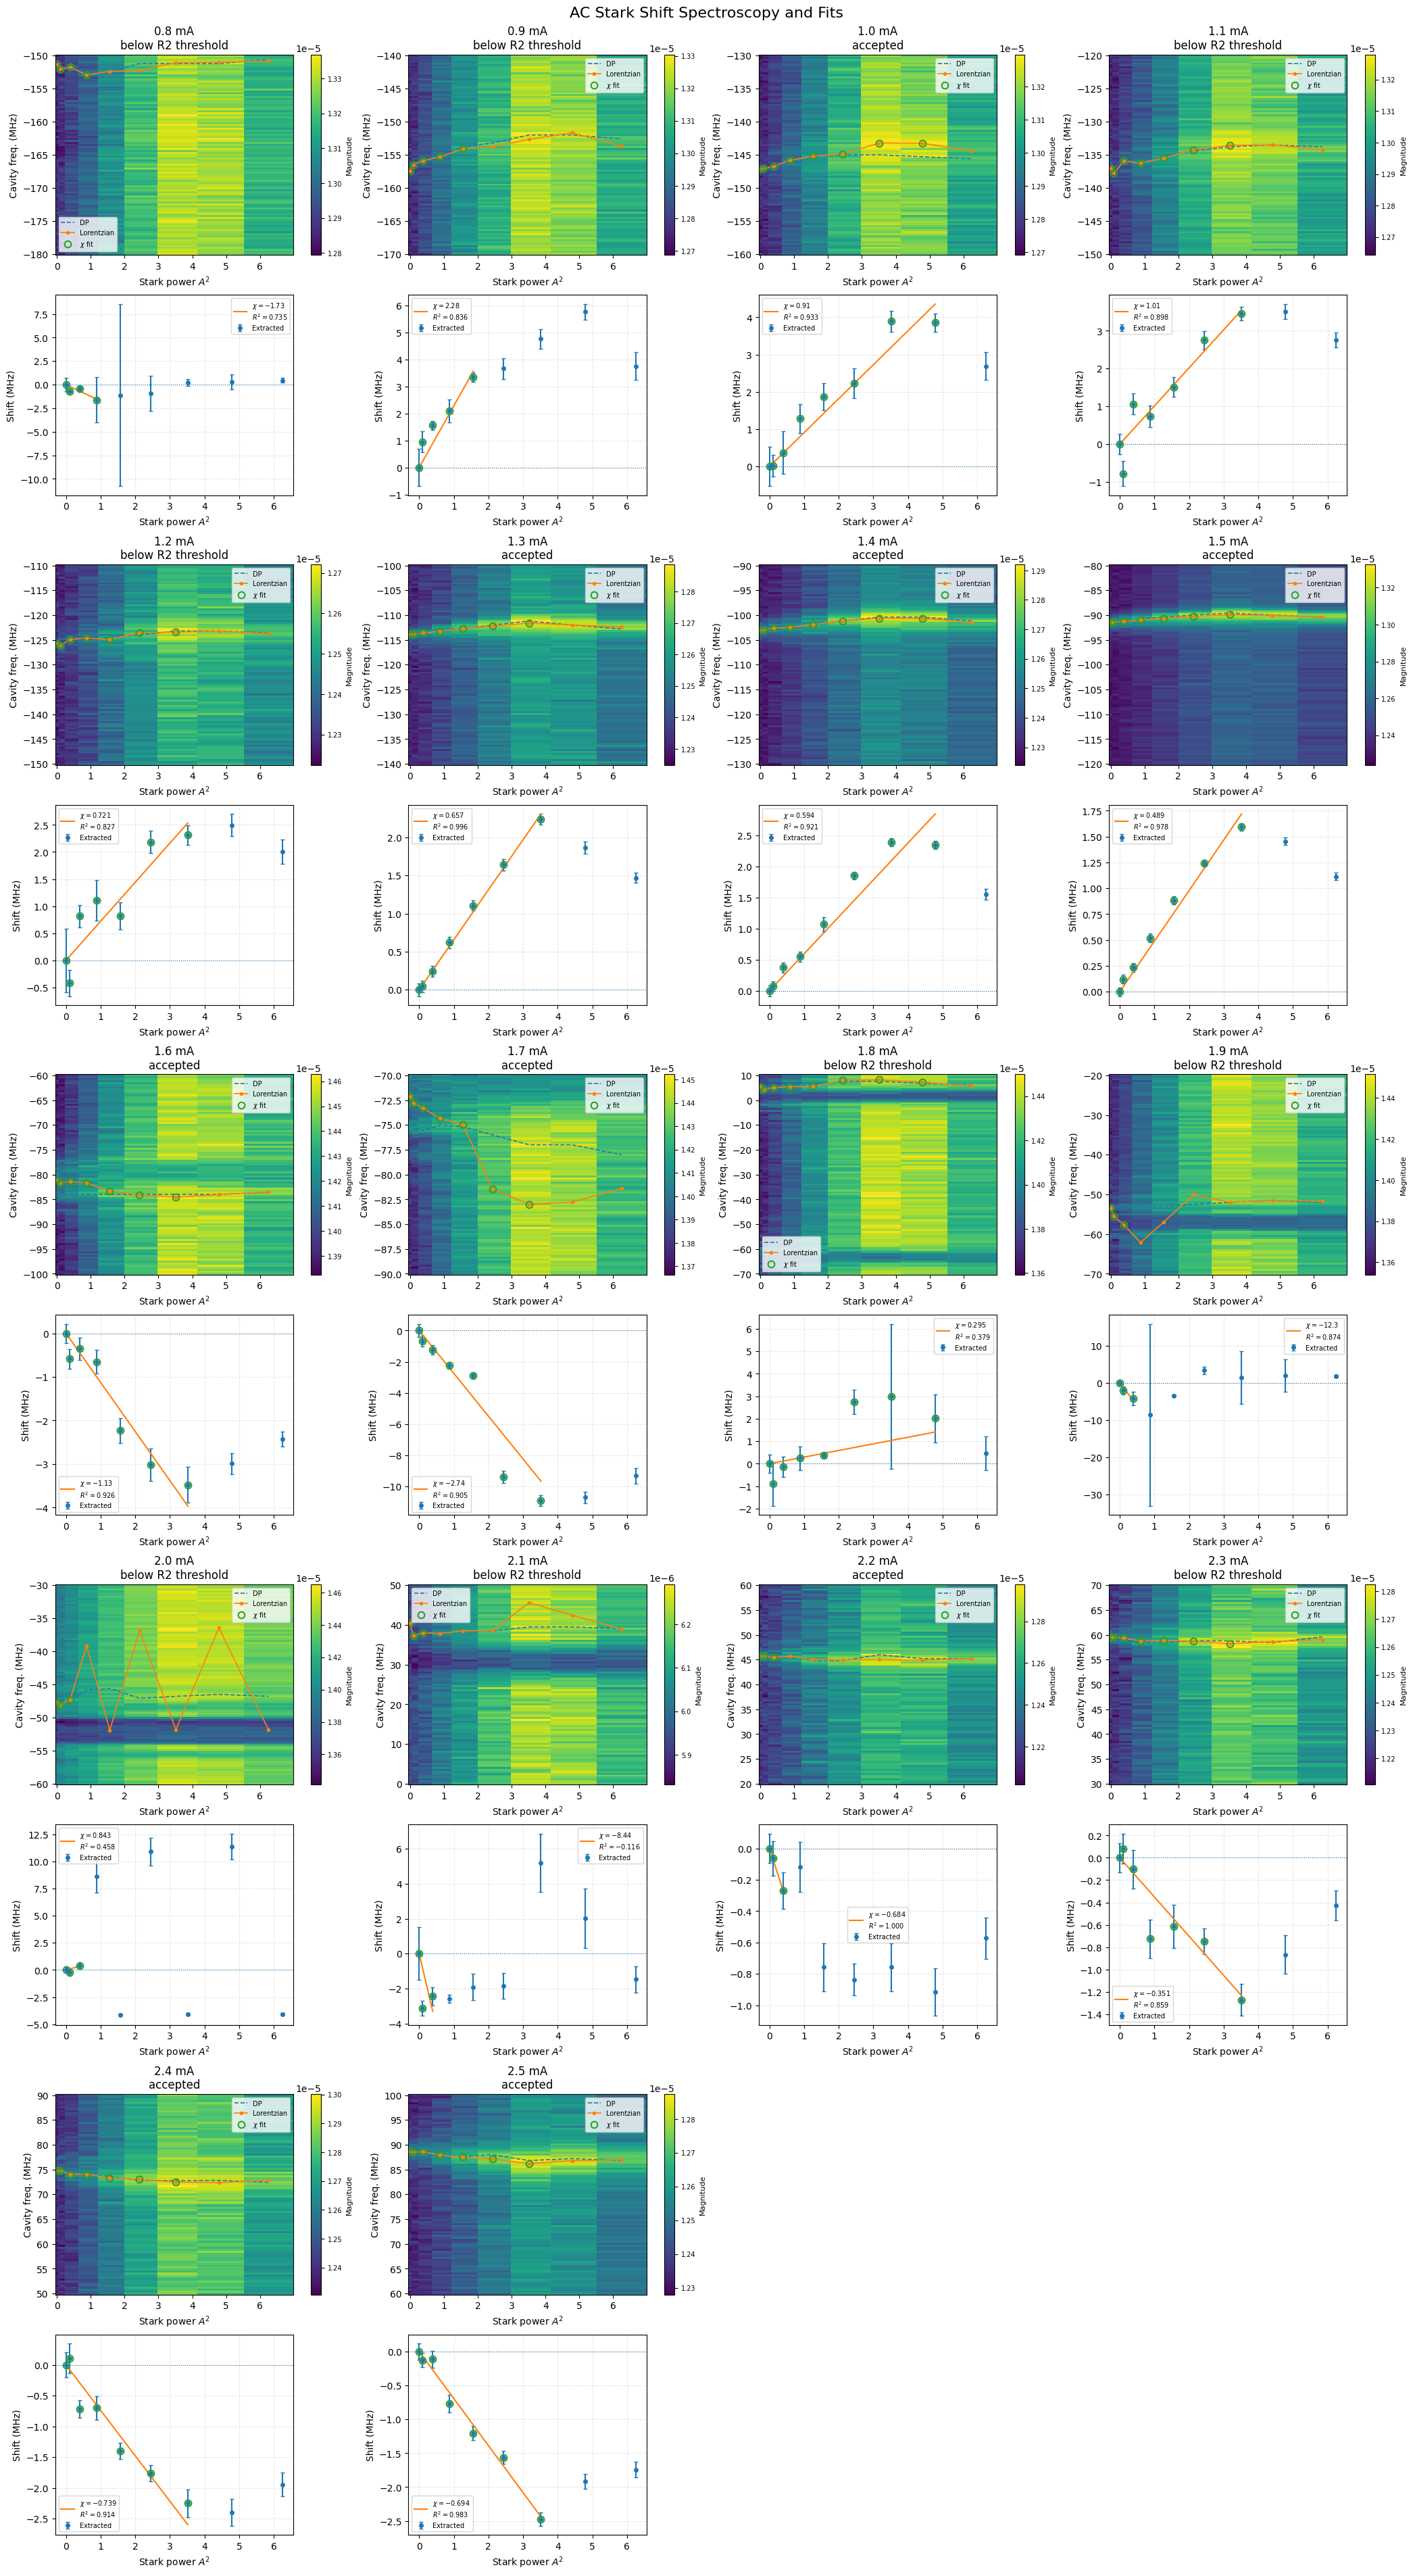

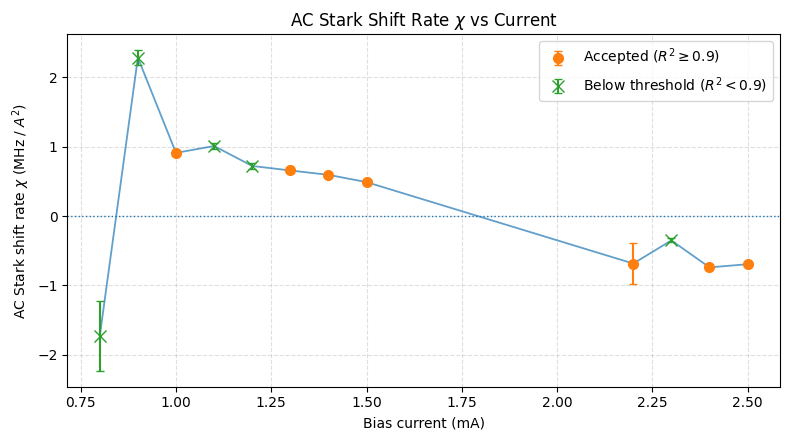


FINAL RESULTS
 Current             chi       chi_err        R2     N    accepted       SNR    peak
    0.80        -1.72797        0.4997    0.7354     4       False      5.36   False
    0.90         2.28136        0.1054    0.8361     5       False      5.13   False
    1.00        0.909893       0.04116    0.9330     8        True      5.81   False
    1.10         1.00889       0.04315    0.8980     7       False      5.40    True
    1.20        0.721393       0.04166    0.8265     7       False      4.23    True
    1.30         0.65651       0.01494    0.9965     7        True      9.14    True
    1.40        0.593768      0.009407    0.9211     8        True      9.03    True
    1.50        0.488918      0.007596    0.9780     7        True     15.55    True
    1.60        -1.12715        0.0787    0.9262     7        True      5.87    True
    1.70        -2.74494       0.06229    0.9053     7        True      4.41    True
    1.80        0.294503       0.05092    0.3787  

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# ==========================================================
# SETTINGS
# ==========================================================

SNR_MIN = 3.5
R2_MIN = 0.90
MAX_SHIFT_MHZ = 50.0
MIN_LINEAR_POINTS = 3
DP_LAMBDA = 0.4


# ==========================================================
# LORENTZIAN
# ==========================================================

def lorentzian(f, f0, gamma, amp, offset):

    return offset + amp * (
        gamma**2
        / ((f - f0)**2 + gamma**2)
    )


# ==========================================================
# ROBUST SNR
# ==========================================================

def robust_snr(z):

    med = np.median(z)

    mad = (
        np.median(
            np.abs(z - med)
        )
        * 1.4826
    )

    if mad == 0:
        return np.inf

    return (
        np.max(z)
        - np.min(z)
    ) / mad


# ==========================================================
# DP RIDGE TRACK
# ==========================================================

def dp_ridge_track(
    f_axis,
    Z_slice,
    lam=DP_LAMBDA,
):

    n_freq, n_power = Z_slice.shape

    med = np.median(
        Z_slice,
        axis=0,
        keepdims=True,
    )

    mad = (
        np.median(
            np.abs(
                Z_slice - med
            ),
            axis=0,
            keepdims=True,
        )
        * 1.4826
    )

    mad[mad == 0] = 1.0

    zscore = (
        Z_slice - med
    ) / mad

    # Track positive feature
    cost = -zscore

    D = np.empty(
        (n_freq, n_power)
    )

    ptr = np.empty(
        (n_freq, n_power),
        dtype=int,
    )

    D[:, 0] = cost[:, 0]

    f_diff2 = (
        f_axis[:, None]
        - f_axis[None, :]
    ) ** 2


    for j in range(
        1,
        n_power,
    ):

        trans = (
            D[None, :, j - 1]
            + lam * f_diff2
        )

        ptr[:, j] = np.argmin(
            trans,
            axis=1,
        )

        D[:, j] = (
            cost[:, j]
            + trans[
                np.arange(n_freq),
                ptr[:, j],
            ]
        )


    path_idx = np.empty(
        n_power,
        dtype=int,
    )

    path_idx[-1] = np.argmin(
        D[:, -1]
    )


    for j in range(
        n_power - 1,
        0,
        -1,
    ):

        path_idx[j - 1] = ptr[
            path_idx[j],
            j,
        ]


    return f_axis[
        path_idx
    ]


# ==========================================================
# LORENTZIAN FIT
# ==========================================================

def fit_lorentzian(
    f_axis,
    z,
    p0,
):

    f_lo = f_axis.min()
    f_hi = f_axis.max()

    span = (
        f_hi - f_lo
    )

    lower = [
        f_lo,
        1e-3,
        -np.inf,
        -np.inf,
    ]

    upper = [
        f_hi,
        span,
        np.inf,
        np.inf,
    ]

    p0 = np.clip(
        p0,
        [
            b + 1e-9
            for b in lower
        ],
        [
            b - 1e-9
            for b in upper
        ],
    )

    try:

        popt, pcov = curve_fit(
            lorentzian,
            f_axis,
            z,
            p0=p0,
            bounds=(
                lower,
                upper,
            ),
            maxfev=4000,
        )

        return popt, pcov

    except Exception:

        return None


# ==========================================================
# REAL PEAK CHECK
# ==========================================================

def has_real_peak(
    z,
    min_width=2,
    z_thresh=2.0,
):

    med = np.median(z)

    mad = (
        np.median(
            np.abs(z - med)
        )
        * 1.4826
    )

    if mad == 0:
        return False

    zscore = (
        z - med
    ) / mad

    i = np.argmax(
        zscore
    )

    half = (
        zscore[i] / 2
    )

    above = (
        zscore
        > max(
            half,
            z_thresh / 2,
        )
    )

    lo = i

    while (
        lo > 0
        and above[lo - 1]
    ):

        lo -= 1

    hi = i

    while (
        hi < len(above) - 1
        and above[hi + 1]
    ):

        hi += 1

    return (
        hi - lo + 1
    ) >= min_width


# ==========================================================
# MAIN
# ==========================================================

def main():

    # ======================================================
    # LOAD DATA
    # ======================================================

    data_path = (
        r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot"
        r"\data_plot_data"
        r"\CavitySpec_stark_shift_2D_current_0.8mA_to_2.5mA.npz"
    )

    data = np.load(
        data_path
    )

    Z = data["Z"]

    cav_freq = data[
        "cavity_frequency"
    ]

    stark_ampx = data[
        "stark_ampx"
    ]

    current_mA = data[
        "current_mA"
    ]


    print(
        "Z shape:",
        Z.shape,
    )

    print(
        "cavity_frequency shape:",
        cav_freq.shape,
    )

    print(
        "stark_ampx shape:",
        stark_ampx.shape,
    )

    print(
        "current [mA]:",
        current_mA,
    )


    # ======================================================
    # RESULTS
    # ======================================================

    summary = []

    plot_results = []


    # ======================================================
    # LOOP OVER CURRENT
    # ======================================================

    for idx in range(
        len(current_mA)
    ):

        current = (
            current_mA[idx]
        )

        print()
        print(
            "=" * 60
        )

        print(
            f"Current = {current:.2f} mA"
        )


        # ==================================================
        # DATA
        # ==================================================

        f_axis = (
            cav_freq[idx]
            / 1e6
        )

        stark_amps = (
            stark_ampx[idx]
        )

        power = (
            stark_amps ** 2
        )

        Z_slice = (
            Z[idx]
        )

        z0 = (
            Z_slice[:, 0]
        )


        # ==================================================
        # QUALITY INFORMATION
        # ==================================================

        snr = robust_snr(
            z0
        )

        peak_ok = has_real_peak(
            z0
        )

        print(
            f"SNR = {snr:.2f}"
        )

        print(
            f"peak check = {peak_ok}"
        )


        # ==================================================
        # DP RIDGE
        # ==================================================

        f0_dp = dp_ridge_track(
            f_axis,
            Z_slice,
            lam=DP_LAMBDA,
        )


        # ==================================================
        # LORENTZIAN FIT
        # ==================================================

        n_power = len(
            stark_amps
        )

        f0_fits = np.full(
            n_power,
            np.nan,
        )

        f0_errs = np.full(
            n_power,
            np.nan,
        )

        gamma_fits = np.full(
            n_power,
            np.nan,
        )

        gamma_guess = 1.5


        for j in range(
            n_power
        ):

            zj = (
                Z_slice[:, j]
            )

            amp_guess = (
                np.max(zj)
                - np.min(zj)
            )

            offset_guess = (
                np.min(zj)
            )

            p0 = [
                f0_dp[j],
                gamma_guess,
                amp_guess,
                offset_guess,
            ]

            fit_j = fit_lorentzian(
                f_axis,
                zj,
                p0,
            )

            if fit_j is None:

                print(
                    f"Fit failed at "
                    f"power index {j}"
                )

                continue


            popt, pcov = (
                fit_j
            )

            perr = np.sqrt(
                np.diag(
                    pcov
                )
            )

            f0_fits[j] = (
                popt[0]
            )

            f0_errs[j] = (
                perr[0]
            )

            gamma_fits[j] = (
                popt[1]
            )

            gamma_guess = max(
                popt[1],
                1e-3,
            )


        # ==================================================
        # VALID FITS
        # ==================================================

        valid = (
            np.isfinite(
                f0_fits
            )
            &
            np.isfinite(
                f0_errs
            )
        )

        n_valid = np.sum(
            valid
        )

        print(
            f"Valid fits = "
            f"{n_valid}/{n_power}"
        )


        # ==================================================
        # TOO FEW FITS
        # ==================================================

        if (
            n_valid
            < MIN_LINEAR_POINTS
        ):

            summary.append(
                {
                    "current_mA":
                        current,

                    "chi":
                        np.nan,

                    "chi_err":
                        np.nan,

                    "n_points":
                        0,

                    "r2":
                        np.nan,

                    "accepted":
                        False,

                    "snr":
                        snr,

                    "peak_ok":
                        peak_ok,
                }
            )

            continue


        # ==================================================
        # FREQUENCY SHIFT
        # ==================================================

        first_valid = np.where(
            valid
        )[0][0]

        f_ref = (
            f0_fits[
                first_valid
            ]
        )

        shifts = (
            f0_fits
            - f_ref
        )


        # ==================================================
        # SEARCH LOW-POWER LINEAR REGION
        # ==================================================

        accepted_k = 0
        accepted_chi = np.nan
        accepted_chi_err = np.nan
        accepted_r2 = -np.inf

        fallback_k = 0
        fallback_chi = np.nan
        fallback_chi_err = np.nan
        fallback_r2 = -np.inf


        for k in range(
            MIN_LINEAR_POINTS,
            len(power) + 1,
        ):

            if not np.all(
                valid[:k]
            ):

                break


            p_sub = (
                power[:k]
            )

            s_sub = (
                shifts[:k]
            )

            e_sub = (
                f0_errs[:k]
            )


            # ==============================================
            # MAX SHIFT CUT
            # ==============================================

            if np.any(
                np.abs(
                    s_sub
                )
                > MAX_SHIFT_MHZ
            ):

                break


            # ==============================================
            # WEIGHTS
            # ==============================================

            w = (
                1.0
                /
                np.clip(
                    e_sub,
                    1e-6,
                    None,
                ) ** 2
            )


            denominator = np.sum(
                w
                * p_sub**2
            )


            if denominator <= 0:

                continue


            # ==============================================
            # FIT THROUGH ORIGIN
            #
            # shift = chi * power
            # ==============================================

            chi = (
                np.sum(
                    w
                    * p_sub
                    * s_sub
                )
                /
                denominator
            )


            chi_err = (
                1.0
                /
                np.sqrt(
                    denominator
                )
            )


            y_pred = (
                chi
                * p_sub
            )


            ss_res = np.sum(
                (
                    s_sub
                    - y_pred
                ) ** 2
            )


            ss_tot = np.sum(
                (
                    s_sub
                    - np.mean(
                        s_sub
                    )
                ) ** 2
            )


            if ss_tot > 0:

                r2 = (
                    1.0
                    - ss_res
                    / ss_tot
                )

            else:

                r2 = 0.0


            # ==============================================
            # FALLBACK
            # ==============================================

            if (
                r2 > fallback_r2
                or
                (
                    np.isclose(
                        r2,
                        fallback_r2,
                    )
                    and
                    k > fallback_k
                )
            ):

                fallback_k = k

                fallback_chi = (
                    chi
                )

                fallback_chi_err = (
                    chi_err
                )

                fallback_r2 = (
                    r2
                )


            # ==============================================
            # ACCEPTED FIT
            # ==============================================

            if (
                r2 >= R2_MIN
                and
                k >= accepted_k
            ):

                accepted_k = (
                    k
                )

                accepted_chi = (
                    chi
                )

                accepted_chi_err = (
                    chi_err
                )

                accepted_r2 = (
                    r2
                )


        # ==================================================
        # SELECT RESULT
        # ==================================================

        if (
            accepted_k
            >= MIN_LINEAR_POINTS
        ):

            best_k = (
                accepted_k
            )

            best_chi = (
                accepted_chi
            )

            best_chi_err = (
                accepted_chi_err
            )

            best_r2 = (
                accepted_r2
            )

            accepted = True

        else:

            best_k = (
                fallback_k
            )

            best_chi = (
                fallback_chi
            )

            best_chi_err = (
                fallback_chi_err
            )

            best_r2 = (
                fallback_r2
            )

            accepted = False


        # ==================================================
        # PRINT RESULT
        # ==================================================

        print(
            f"chi = "
            f"{best_chi:.6g} MHz/A^2"
        )

        print(
            f"R2 = "
            f"{best_r2:.4f}"
        )

        print(
            f"N = "
            f"{best_k}"
        )

        print(
            f"accepted = "
            f"{accepted}"
        )


        # ==================================================
        # STORE SUMMARY
        # ==================================================

        summary.append(
            {
                "current_mA":
                    current,

                "chi":
                    best_chi,

                "chi_err":
                    best_chi_err,

                "n_points":
                    best_k,

                "r2":
                    best_r2,

                "accepted":
                    accepted,

                "snr":
                    snr,

                "peak_ok":
                    peak_ok,
            }
        )


        # ==================================================
        # STORE FOR SUBPLOTS
        # ==================================================

        plot_results.append(
            {
                "current":
                    current,

                "power":
                    power.copy(),

                "f_axis":
                    f_axis.copy(),

                "Z_slice":
                    Z_slice.copy(),

                "f0_dp":
                    f0_dp.copy(),

                "f0_fits":
                    f0_fits.copy(),

                "f0_errs":
                    f0_errs.copy(),

                "valid":
                    valid.copy(),

                "shifts":
                    shifts.copy(),

                "best_k":
                    best_k,

                "best_chi":
                    best_chi,

                "best_chi_err":
                    best_chi_err,

                "best_r2":
                    best_r2,

                "accepted":
                    accepted,
            }
        )


    # ==========================================================
    # 2D + FIT SUBPLOTS
    # ==========================================================

    nplots = len(
        plot_results
    )


    if nplots > 0:

        ncols = 4

        ngroups = int(
            np.ceil(
                nplots / ncols
            )
        )

        nrows = (
            2 * ngroups
        )


        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(
                5.2 * ncols,
                3.8 * nrows,
            ),
            constrained_layout=True,
        )


        axes = np.asarray(
            axes
        )


        if axes.ndim == 1:

            axes = axes.reshape(
                nrows,
                ncols,
            )


        # ======================================================
        # EACH CURRENT
        # ======================================================

        for i, result in enumerate(
            plot_results
        ):

            group = (
                i // ncols
            )

            col = (
                i % ncols
            )

            row_2d = (
                2 * group
            )

            row_fit = (
                row_2d + 1
            )


            ax2d = axes[
                row_2d,
                col,
            ]

            axfit = axes[
                row_fit,
                col,
            ]


            current = (
                result["current"]
            )

            power = (
                result["power"]
            )

            f_axis = (
                result["f_axis"]
            )

            Z_slice = (
                result["Z_slice"]
            )

            f0_dp = (
                result["f0_dp"]
            )

            f0_fits = (
                result["f0_fits"]
            )

            f0_errs = (
                result["f0_errs"]
            )

            valid = (
                result["valid"]
            )

            shifts = (
                result["shifts"]
            )

            best_k = (
                result["best_k"]
            )

            best_chi = (
                result["best_chi"]
            )

            best_r2 = (
                result["best_r2"]
            )

            accepted = (
                result["accepted"]
            )


            # ==================================================
            # TOP: 2D SPECTROSCOPY
            # ==================================================

            pcm = ax2d.pcolormesh(
                power,
                f_axis,
                Z_slice,
                shading="auto",
            )


            ax2d.plot(
                power,
                f0_dp,
                "--",
                linewidth=1.2,
                label="DP",
            )


            ax2d.plot(
                power[valid],
                f0_fits[valid],
                "o-",
                markersize=3,
                linewidth=1.2,
                label="Lorentzian",
            )


            if (
                best_k
                >= MIN_LINEAR_POINTS
            ):

                ax2d.plot(
                    power[:best_k],
                    f0_fits[:best_k],
                    "o",
                    markersize=7,
                    markerfacecolor="none",
                    markeredgewidth=1.5,
                    label=r"$\chi$ fit",
                )


            if accepted:

                status = (
                    "accepted"
                )

            else:

                status = (
                    "below R2 threshold"
                )


            ax2d.set_title(
                f"{current:.1f} mA\n"
                f"{status}"
            )


            ax2d.set_xlabel(
                r"Stark power $A^2$"
            )


            ax2d.set_ylabel(
                "Cavity freq. (MHz)"
            )


            ax2d.legend(
                fontsize=7,
                loc="best",
            )


            cbar = fig.colorbar(
                pcm,
                ax=ax2d,
                pad=0.01,
            )


            cbar.set_label(
                "Magnitude",
                fontsize=8,
            )


            cbar.ax.tick_params(
                labelsize=7
            )


            # ==================================================
            # BOTTOM: SHIFT VS POWER
            # ==================================================

            axfit.errorbar(
                power[valid],
                shifts[valid],
                yerr=f0_errs[valid],
                fmt="o",
                markersize=4,
                capsize=2,
                label="Extracted",
            )


            if (
                best_k
                >= MIN_LINEAR_POINTS
                and
                np.isfinite(
                    best_chi
                )
            ):

                p_fit = np.linspace(
                    0,
                    power[
                        best_k - 1
                    ],
                    200,
                )


                axfit.plot(
                    p_fit,
                    best_chi
                    * p_fit,
                    "-",
                    linewidth=1.5,
                    label=(
                        rf"$\chi="
                        rf"{best_chi:.3g}$"
                        "\n"
                        rf"$R^2="
                        rf"{best_r2:.3f}$"
                    ),
                )


                axfit.plot(
                    power[:best_k],
                    shifts[:best_k],
                    "o",
                    markersize=7,
                    markerfacecolor="none",
                    markeredgewidth=1.5,
                )


            axfit.axhline(
                0,
                linestyle=":",
                linewidth=0.8,
            )


            axfit.set_xlabel(
                r"Stark power $A^2$"
            )


            axfit.set_ylabel(
                "Shift (MHz)"
            )


            axfit.grid(
                True,
                linestyle="--",
                alpha=0.3,
            )


            axfit.legend(
                fontsize=7,
                loc="best",
            )


        # ======================================================
        # HIDE EMPTY PANELS
        # ======================================================

        total_slots = (
            ngroups
            * ncols
        )


        for i in range(
            nplots,
            total_slots,
        ):

            group = (
                i // ncols
            )

            col = (
                i % ncols
            )


            axes[
                2 * group,
                col,
            ].set_visible(
                False
            )


            axes[
                2 * group + 1,
                col,
            ].set_visible(
                False
            )


        fig.suptitle(
            "AC Stark Shift Spectroscopy and Fits",
            fontsize=16,
        )


        plt.show()


    # ==========================================================
    # FINAL CHI VS CURRENT
    # ==========================================================

    summary.sort(
        key=lambda x:
        x["current_mA"]
    )


    currents = np.array([
        r["current_mA"]
        for r in summary
    ])


    chis = np.array([
        r["chi"]
        for r in summary
    ])


    chi_errs = np.array([
        r["chi_err"]
        for r in summary
    ])


    accepted_array = np.array([
        r["accepted"]
        for r in summary
    ])


    # ==========================================================
    # VALID FITS
    # ==========================================================

    finite = (
        np.isfinite(
            chis
        )
        &
        np.isfinite(
            chi_errs
        )
    )


    # ==========================================================
    # REMOVE 1.6 TO 2.1 mA
    # ONLY FROM FINAL PLOT
    # ==========================================================

    current_keep = ~(
        (currents >= 1.6)
        &
        (currents <= 2.1)
    )


    plot_mask = (
        finite
        &
        current_keep
    )


    # ==========================================================
    # FINAL PLOT
    # ==========================================================

    fig, ax = plt.subplots(
        figsize=(8, 4.5)
    )


    # ==========================================================
    # CONNECT DISPLAYED POINTS
    # ==========================================================

    ax.plot(
        currents[
            plot_mask
        ],
        chis[
            plot_mask
        ],
        "-",
        linewidth=1.3,
        alpha=0.7,
    )


    # ==========================================================
    # ACCEPTED FITS
    # ==========================================================

    good = (
        plot_mask
        &
        accepted_array
    )


    ax.errorbar(
        currents[
            good
        ],
        chis[
            good
        ],
        yerr=chi_errs[
            good
        ],
        fmt="o",
        markersize=7,
        capsize=3,
        label=(
            rf"Accepted "
            rf"($R^2 \geq {R2_MIN}$)"
        ),
    )


    # ==========================================================
    # BELOW R2 THRESHOLD
    # ==========================================================

    bad = (
        plot_mask
        &
        ~accepted_array
    )


    ax.errorbar(
        currents[
            bad
        ],
        chis[
            bad
        ],
        yerr=chi_errs[
            bad
        ],
        fmt="x",
        markersize=8,
        capsize=3,
        label=(
            rf"Below threshold "
            rf"($R^2 < {R2_MIN}$)"
        ),
    )


    ax.set_xlabel(
        "Bias current (mA)"
    )


    ax.set_ylabel(
        r"AC Stark shift rate "
        r"$\chi$ (MHz / $A^2$)"
    )


    ax.axhline(
        0,
        linestyle=":",
        linewidth=1,
    )


    ax.grid(
        True,
        linestyle="--",
        alpha=0.4,
    )


    ax.legend()


    ax.set_title(
        r"AC Stark Shift Rate "
        r"$\chi$ vs Current"
    )


    plt.tight_layout()

    plt.show()


    # ==========================================================
    # PRINT ALL RESULTS
    #
    # NOTE:
    # 1.6–2.1 mA are STILL printed here.
    # They are excluded only from the final plot.
    # ==========================================================

    print()
    print(
        "=" * 100
    )

    print(
        "FINAL RESULTS"
    )

    print(
        "=" * 100
    )


    print(
        f"{'Current':>8}  "
        f"{'chi':>14}  "
        f"{'chi_err':>12}  "
        f"{'R2':>8}  "
        f"{'N':>4}  "
        f"{'accepted':>10}  "
        f"{'SNR':>8}  "
        f"{'peak':>6}"
    )


    for r in summary:

        print(
            f"{r['current_mA']:8.2f}  "
            f"{r['chi']:14.6g}  "
            f"{r['chi_err']:12.4g}  "
            f"{r['r2']:8.4f}  "
            f"{r['n_points']:4d}  "
            f"{str(r['accepted']):>10}  "
            f"{r['snr']:8.2f}  "
            f"{str(r['peak_ok']):>6}"
        )


    return summary


# ==========================================================
# RUN
# ==========================================================

if __name__ == "__main__":

    results = main()

Z shape: (18, 101, 9)
cavity_frequency shape: (18, 101)
stark_ampx shape: (18, 9)
current [mA]: [0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5]

Current = 0.80 mA
SNR = 5.36
Rejected: no real peak

Current = 0.90 mA
SNR = 5.13
Rejected: no real peak

Current = 1.00 mA
SNR = 5.81
Rejected: no real peak

Current = 1.10 mA
SNR = 5.40
Valid Lorentzian fits: 9 / 9
No accepted linear Stark region

Current = 1.20 mA
SNR = 4.23
Valid Lorentzian fits: 9 / 9
No accepted linear Stark region

Current = 1.30 mA
SNR = 9.14
Valid Lorentzian fits: 9 / 9
χ = 0.65651 MHz/A²
R² = 0.9965
Points used = 7

Current = 1.40 mA
SNR = 9.03
Valid Lorentzian fits: 9 / 9
χ = 0.593768 MHz/A²
R² = 0.9211
Points used = 8

Current = 1.50 mA
SNR = 15.55
Valid Lorentzian fits: 9 / 9
χ = 0.488918 MHz/A²
R² = 0.9780
Points used = 7

Current = 1.60 mA
SNR = 5.87
Valid Lorentzian fits: 9 / 9
χ = -1.12715 MHz/A²
R² = 0.9262
Points used = 7

Current = 1.70 mA
SNR = 4.41
Valid Lorentzian fits: 9 / 9
χ 

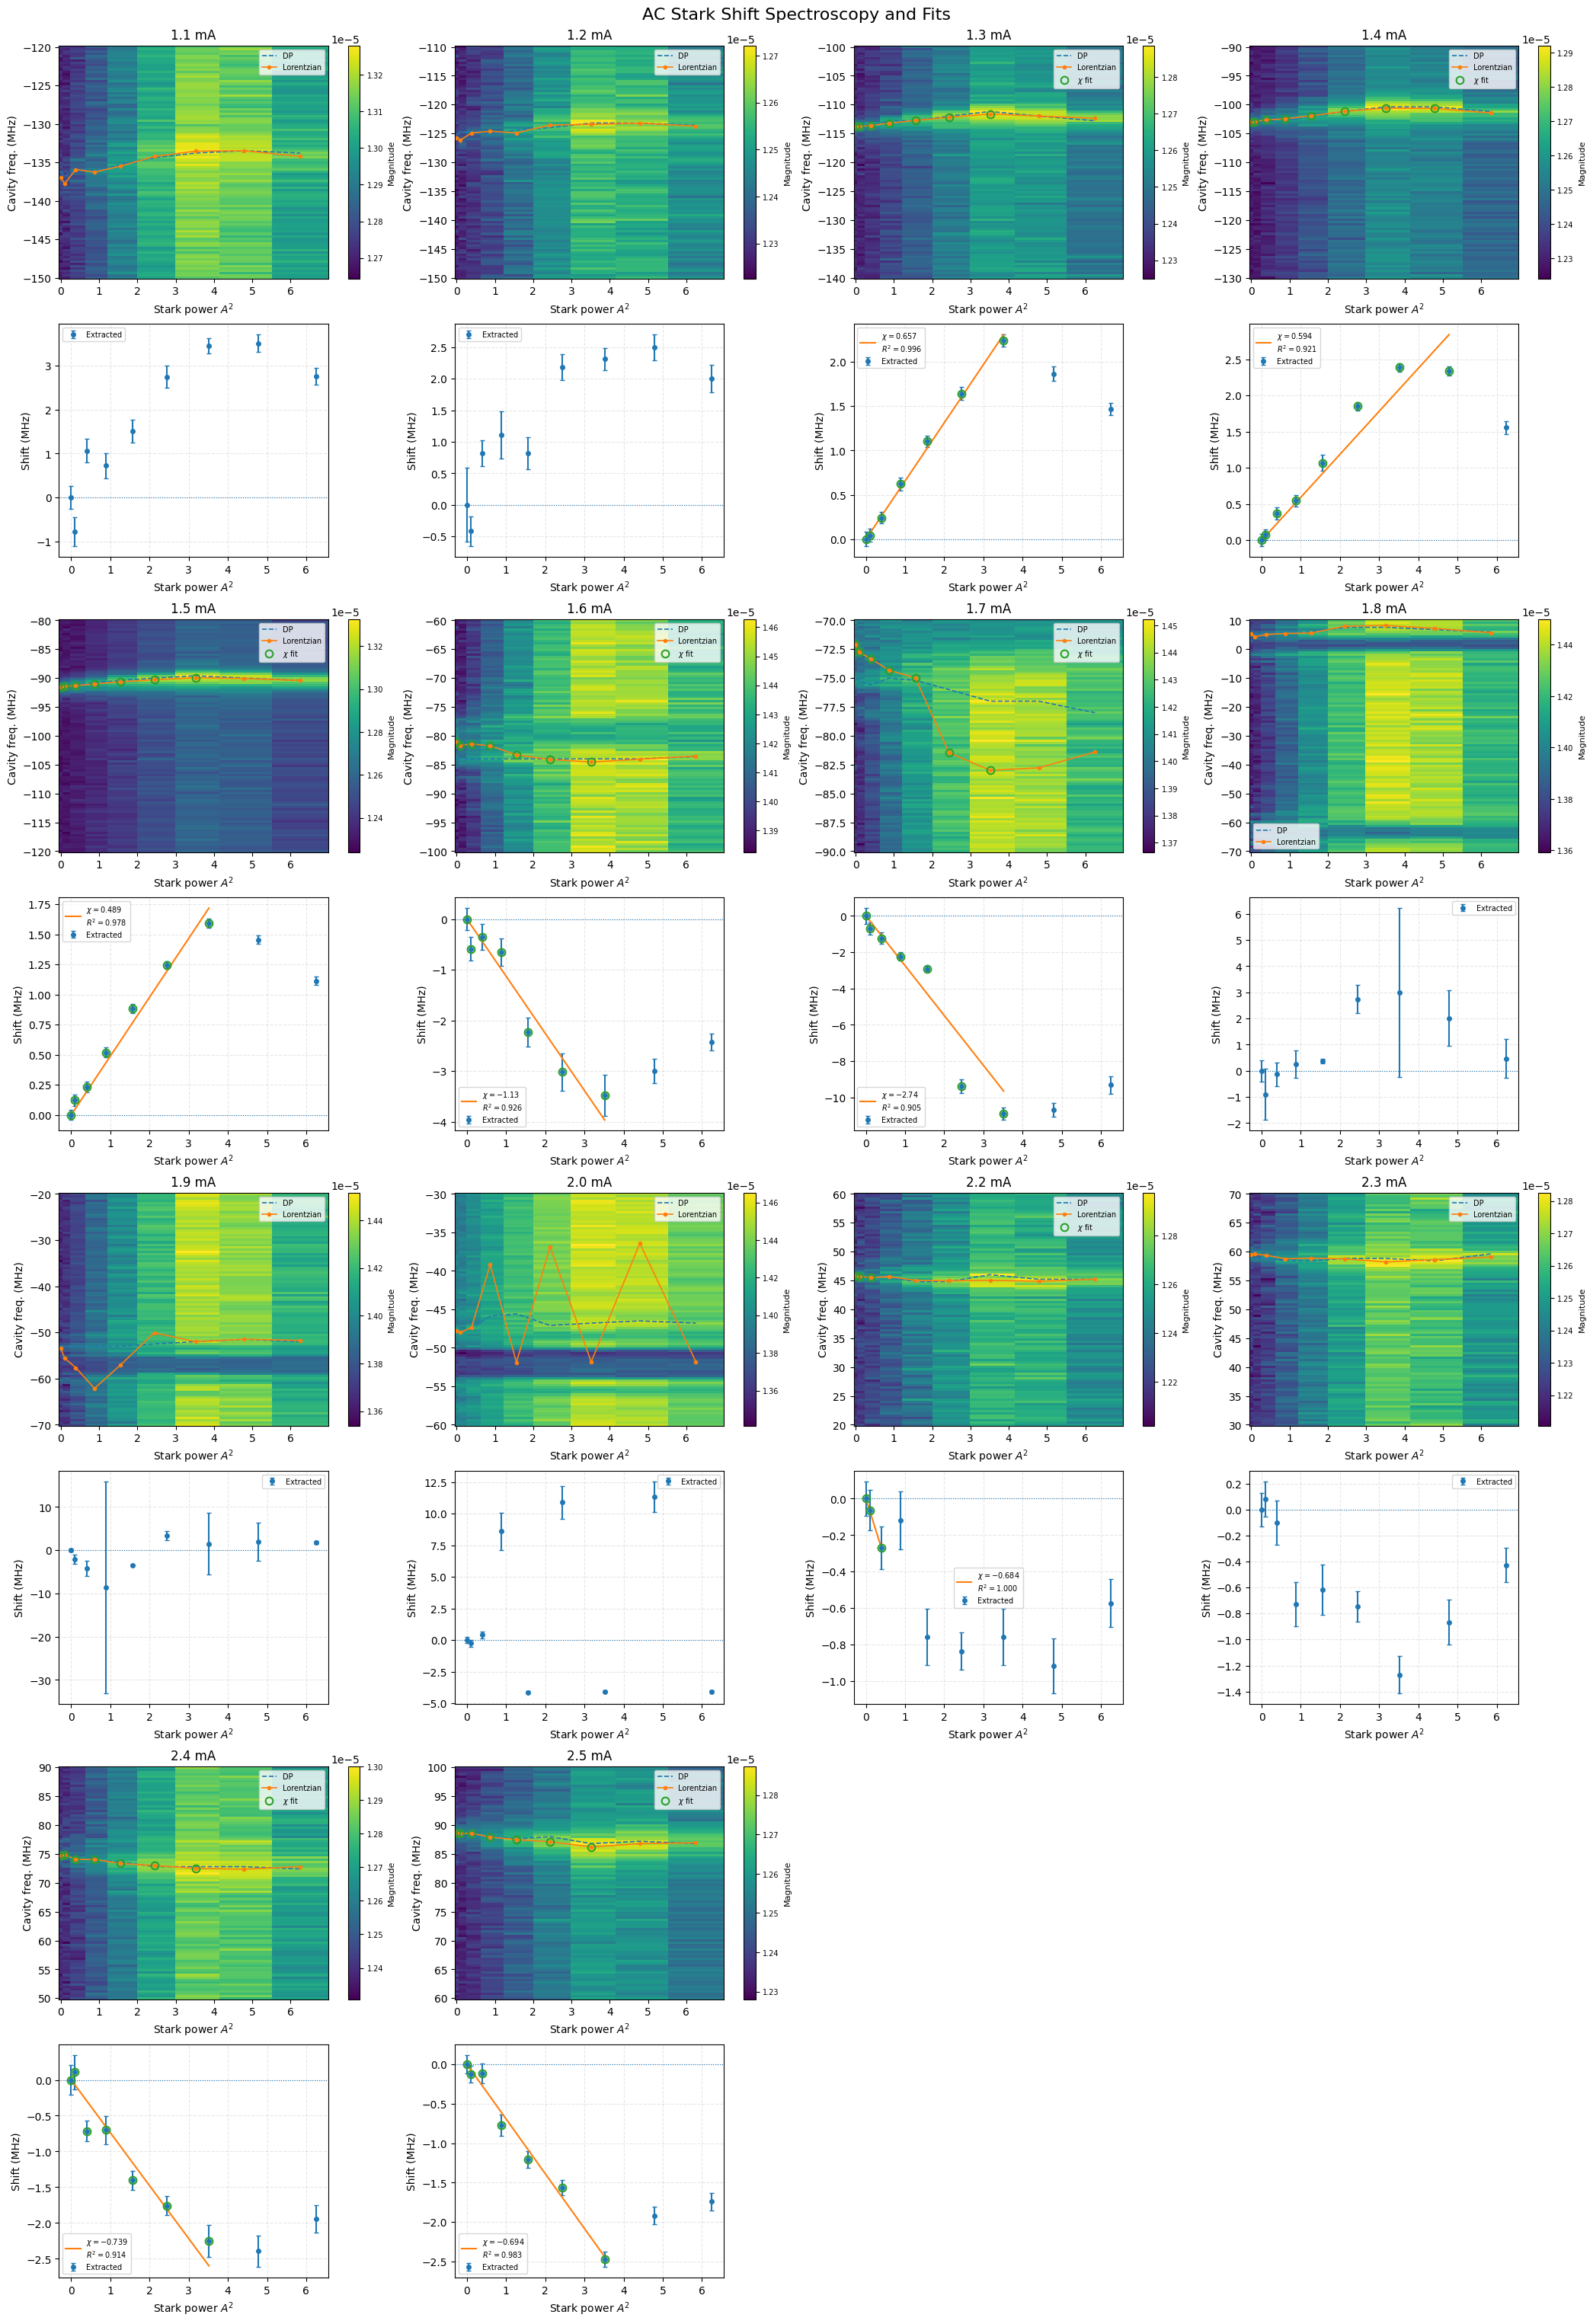

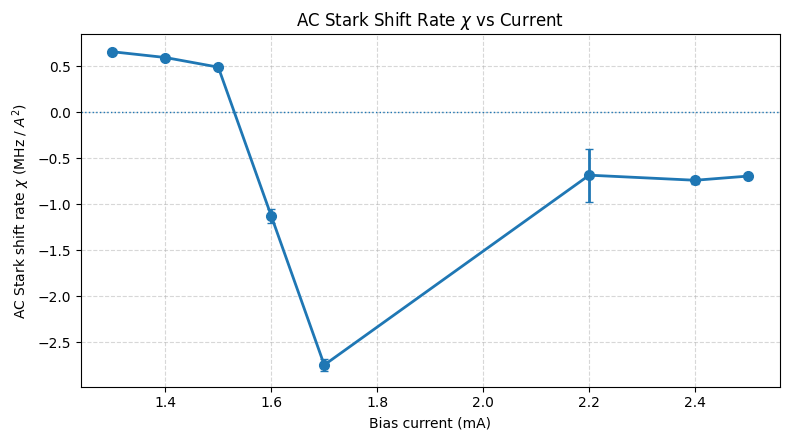


FINAL RESULTS
 1.3 mA   chi =      0.65651   +/- 0.0149   R2 = 0.9965   N = 7
 1.4 mA   chi =     0.593768   +/- 0.00941   R2 = 0.9211   N = 8
 1.5 mA   chi =     0.488918   +/- 0.0076   R2 = 0.9780   N = 7
 1.6 mA   chi =     -1.12715   +/- 0.0787   R2 = 0.9262   N = 7
 1.7 mA   chi =     -2.74494   +/- 0.0623   R2 = 0.9053   N = 7
 2.2 mA   chi =    -0.684027   +/- 0.289   R2 = 0.9997   N = 3
 2.4 mA   chi =    -0.739161   +/- 0.0365   R2 = 0.9138   N = 7
 2.5 mA   chi =    -0.693776   +/- 0.021   R2 = 0.9831   N = 7


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# ==========================================================
# SETTINGS
# ==========================================================

SNR_MIN = 3.5
R2_MIN = 0.90
MAX_SHIFT_MHZ = 50.0
MIN_LINEAR_POINTS = 3
DP_LAMBDA = 0.4


# ==========================================================
# LORENTZIAN
# ==========================================================

def lorentzian(f, f0, gamma, amp, offset):
    return offset + amp * (
        gamma**2
        / ((f - f0)**2 + gamma**2)
    )


# ==========================================================
# ROBUST SNR
# ==========================================================

def robust_snr(z):

    med = np.median(z)

    mad = (
        np.median(
            np.abs(z - med)
        )
        * 1.4826
    )

    if mad == 0:
        return np.inf

    return (
        np.max(z)
        - np.min(z)
    ) / mad


# ==========================================================
# DP RIDGE TRACKING
# ==========================================================

def dp_ridge_track(
    f_axis,
    Z_slice,
    lam=DP_LAMBDA,
):

    n_freq, n_power = Z_slice.shape

    med = np.median(
        Z_slice,
        axis=0,
        keepdims=True,
    )

    mad = (
        np.median(
            np.abs(
                Z_slice - med
            ),
            axis=0,
            keepdims=True,
        )
        * 1.4826
    )

    mad[mad == 0] = 1.0

    zscore = (
        Z_slice - med
    ) / mad

    # Track strong positive feature
    cost = -zscore

    D = np.empty(
        (n_freq, n_power)
    )

    ptr = np.empty(
        (n_freq, n_power),
        dtype=int,
    )

    D[:, 0] = cost[:, 0]

    f_diff2 = (
        f_axis[:, None]
        - f_axis[None, :]
    ) ** 2


    for j in range(
        1,
        n_power,
    ):

        trans = (
            D[None, :, j - 1]
            + lam * f_diff2
        )

        ptr[:, j] = np.argmin(
            trans,
            axis=1,
        )

        D[:, j] = (
            cost[:, j]
            + trans[
                np.arange(n_freq),
                ptr[:, j],
            ]
        )


    path_idx = np.empty(
        n_power,
        dtype=int,
    )

    path_idx[-1] = np.argmin(
        D[:, -1]
    )


    for j in range(
        n_power - 1,
        0,
        -1,
    ):

        path_idx[j - 1] = (
            ptr[
                path_idx[j],
                j,
            ]
        )


    return f_axis[
        path_idx
    ]


# ==========================================================
# LORENTZIAN FIT
# ==========================================================

def fit_lorentzian(
    f_axis,
    z,
    p0,
):

    f_lo = f_axis.min()
    f_hi = f_axis.max()

    span = (
        f_hi - f_lo
    )

    lower = [
        f_lo,
        1e-3,
        -np.inf,
        -np.inf,
    ]

    upper = [
        f_hi,
        span,
        np.inf,
        np.inf,
    ]


    p0 = np.clip(
        p0,
        [
            b + 1e-9
            for b in lower
        ],
        [
            b - 1e-9
            for b in upper
        ],
    )


    try:

        popt, pcov = curve_fit(
            lorentzian,
            f_axis,
            z,
            p0=p0,
            bounds=(
                lower,
                upper,
            ),
            maxfev=4000,
        )

        return popt, pcov

    except Exception:
        return None


# ==========================================================
# REAL PEAK CHECK
# ==========================================================

def has_real_peak(
    z,
    min_width=2,
    z_thresh=2.0,
):

    med = np.median(z)

    mad = (
        np.median(
            np.abs(z - med)
        )
        * 1.4826
    )

    if mad == 0:
        return False


    zscore = (
        z - med
    ) / mad


    i = np.argmax(
        zscore
    )

    half = (
        zscore[i] / 2
    )


    above = (
        zscore
        > max(
            half,
            z_thresh / 2,
        )
    )


    lo = i

    while (
        lo > 0
        and above[lo - 1]
    ):

        lo -= 1


    hi = i

    while (
        hi < len(above) - 1
        and above[hi + 1]
    ):

        hi += 1


    return (
        hi - lo + 1
    ) >= min_width


# ==========================================================
# MAIN
# ==========================================================

def main():

    # ======================================================
    # LOAD DATA
    # ======================================================

    data_path = (
        r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot"
        r"\data_plot_data"
        r"\CavitySpec_stark_shift_2D_current_0.8mA_to_2.5mA.npz"
    )


    data = np.load(
        data_path
    )


    Z = data["Z"]

    cav_freq = data[
        "cavity_frequency"
    ]

    stark_ampx = data[
        "stark_ampx"
    ]

    current_mA = data[
        "current_mA"
    ]


    print(
        "Z shape:",
        Z.shape,
    )

    print(
        "cavity_frequency shape:",
        cav_freq.shape,
    )

    print(
        "stark_ampx shape:",
        stark_ampx.shape,
    )

    print(
        "current [mA]:",
        current_mA,
    )


    # ======================================================
    # RESULTS
    # ======================================================

    dynamic_summary = []

    plot_results = []


    # ======================================================
    # LOOP OVER CURRENT
    # ======================================================

    for idx in range(
        len(current_mA)
    ):

        current = (
            current_mA[idx]
        )


        print()
        print(
            "=" * 60
        )

        print(
            f"Current = "
            f"{current:.2f} mA"
        )


        # ==================================================
        # EXTRACT DATA
        # ==================================================

        f_axis = (
            cav_freq[idx]
            / 1e6
        )

        stark_amps = (
            stark_ampx[idx]
        )

        power = (
            stark_amps ** 2
        )

        Z_slice = (
            Z[idx]
        )

        z0 = (
            Z_slice[:, 0]
        )


        # ==================================================
        # QUALITY CHECK
        # ==================================================

        snr = robust_snr(
            z0
        )


        print(
            f"SNR = {snr:.2f}"
        )


        if snr < SNR_MIN:

            print(
                "Rejected: low SNR"
            )

            continue


        if not has_real_peak(
            z0
        ):

            print(
                "Rejected: no real peak"
            )

            continue


        # ==================================================
        # DP RIDGE
        # ==================================================

        f0_dp = dp_ridge_track(
            f_axis,
            Z_slice,
            lam=DP_LAMBDA,
        )


        # ==================================================
        # LORENTZIAN FIT
        # ==================================================

        n_power = len(
            stark_amps
        )


        f0_fits = np.full(
            n_power,
            np.nan,
        )

        f0_errs = np.full(
            n_power,
            np.nan,
        )

        gamma_fits = np.full(
            n_power,
            np.nan,
        )


        gamma_guess = 1.5


        for j in range(
            n_power
        ):

            zj = (
                Z_slice[:, j]
            )


            amp_guess = (
                np.max(zj)
                - np.min(zj)
            )


            offset_guess = (
                np.min(zj)
            )


            p0 = [
                f0_dp[j],
                gamma_guess,
                amp_guess,
                offset_guess,
            ]


            fit_j = fit_lorentzian(
                f_axis,
                zj,
                p0,
            )


            if fit_j is None:

                print(
                    f"Fit failed at "
                    f"power index {j}"
                )

                continue


            popt, pcov = (
                fit_j
            )


            perr = np.sqrt(
                np.diag(
                    pcov
                )
            )


            f0_fits[j] = (
                popt[0]
            )

            f0_errs[j] = (
                perr[0]
            )

            gamma_fits[j] = (
                popt[1]
            )


            gamma_guess = max(
                popt[1],
                1e-3,
            )


        # ==================================================
        # VALID FITS
        # ==================================================

        valid = (
            np.isfinite(
                f0_fits
            )
            &
            np.isfinite(
                f0_errs
            )
        )


        print(
            "Valid Lorentzian fits:",
            np.sum(valid),
            "/",
            n_power,
        )


        if (
            np.sum(valid)
            < MIN_LINEAR_POINTS
        ):

            print(
                "Rejected: "
                "not enough fits"
            )

            continue


        # ==================================================
        # REFERENCE FREQUENCY
        # ==================================================

        first_valid = (
            np.where(
                valid
            )[0][0]
        )


        f_ref = (
            f0_fits[
                first_valid
            ]
        )


        shifts = (
            f0_fits
            - f_ref
        )


        # ==================================================
        # FIND LINEAR LOW POWER REGION
        # ==================================================

        best_k = 0

        best_chi = np.nan

        best_chi_err = np.nan

        best_r2 = -1.0


        for k in range(
            MIN_LINEAR_POINTS,
            len(power) + 1,
        ):

            # We want a contiguous
            # low-power region
            if not np.all(
                valid[:k]
            ):

                break


            p_sub = (
                power[:k]
            )

            s_sub = (
                shifts[:k]
            )

            e_sub = (
                f0_errs[:k]
            )


            if np.any(
                np.abs(
                    s_sub
                )
                > MAX_SHIFT_MHZ
            ):

                break


            # ==============================================
            # WEIGHTED FIT THROUGH ORIGIN
            #
            # shift = chi * power
            # ==============================================

            w = (
                1.0
                /
                np.clip(
                    e_sub,
                    1e-6,
                    None,
                ) ** 2
            )


            denominator = (
                np.sum(
                    w
                    * p_sub ** 2
                )
            )


            if denominator == 0:
                continue


            chi = (
                np.sum(
                    w
                    * p_sub
                    * s_sub
                )
                /
                denominator
            )


            chi_err = (
                1.0
                /
                np.sqrt(
                    denominator
                )
            )


            y_pred = (
                chi
                * p_sub
            )


            ss_res = (
                np.sum(
                    (
                        s_sub
                        - y_pred
                    ) ** 2
                )
            )


            ss_tot = (
                np.sum(
                    (
                        s_sub
                        - np.mean(
                            s_sub
                        )
                    ) ** 2
                )
            )


            if ss_tot > 0:

                r2 = (
                    1.0
                    - ss_res
                    / ss_tot
                )

            else:

                r2 = 0.0


            if (
                r2 >= R2_MIN
                and
                k >= best_k
            ):

                best_k = k

                best_chi = chi

                best_chi_err = (
                    chi_err
                )

                best_r2 = r2


        # ==================================================
        # PRINT RESULT
        # ==================================================

        if (
            best_k
            >= MIN_LINEAR_POINTS
        ):

            print(
                f"χ = "
                f"{best_chi:.6g} "
                f"MHz/A²"
            )

            print(
                f"R² = "
                f"{best_r2:.4f}"
            )

            print(
                f"Points used = "
                f"{best_k}"
            )


            dynamic_summary.append(
                {
                    "current_mA":
                        current,

                    "chi":
                        best_chi,

                    "chi_err":
                        best_chi_err,

                    "n_points":
                        best_k,

                    "r2":
                        best_r2,
                }
            )

        else:

            print(
                "No accepted "
                "linear Stark region"
            )


        # ==================================================
        # STORE FOR SUBPLOT
        # ==================================================

        plot_results.append(
            {
                "current":
                    current,

                "power":
                    power.copy(),

                "f_axis":
                    f_axis.copy(),

                "Z_slice":
                    Z_slice.copy(),

                "f0_dp":
                    f0_dp.copy(),

                "f0_fits":
                    f0_fits.copy(),

                "f0_errs":
                    f0_errs.copy(),

                "valid":
                    valid.copy(),

                "shifts":
                    shifts.copy(),

                "best_k":
                    best_k,

                "best_chi":
                    best_chi,

                "best_chi_err":
                    best_chi_err,

                "best_r2":
                    best_r2,
            }
        )


    # ==========================================================
    # SUBPLOT FIGURE
    #
    # 4 currents per group
    #
    # row 1: 2D spectroscopy
    # row 2: shift fit
    #
    # then repeat
    # ==========================================================

    nplots = len(
        plot_results
    )


    if nplots == 0:

        raise RuntimeError(
            "No current points "
            "passed the initial "
            "data-quality criteria."
        )


    ncols = 4

    ngroups = int(
        np.ceil(
            nplots / ncols
        )
    )

    nrows = (
        2 * ngroups
    )


    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(
            5.2 * ncols,
            3.8 * nrows,
        ),
        constrained_layout=True,
    )


    axes = np.asarray(
        axes
    )


    if axes.ndim == 1:

        axes = (
            axes.reshape(
                nrows,
                ncols,
            )
        )


    # ======================================================
    # PLOT EACH CURRENT
    # ======================================================

    for i, result in enumerate(
        plot_results
    ):

        group = (
            i // ncols
        )

        col = (
            i % ncols
        )


        row_2d = (
            2 * group
        )

        row_fit = (
            row_2d + 1
        )


        ax2d = (
            axes[
                row_2d,
                col,
            ]
        )

        axfit = (
            axes[
                row_fit,
                col,
            ]
        )


        # ==================================================
        # GET DATA
        # ==================================================

        current = (
            result[
                "current"
            ]
        )

        power = (
            result[
                "power"
            ]
        )

        f_axis = (
            result[
                "f_axis"
            ]
        )

        Z_slice = (
            result[
                "Z_slice"
            ]
        )

        f0_dp = (
            result[
                "f0_dp"
            ]
        )

        f0_fits = (
            result[
                "f0_fits"
            ]
        )

        f0_errs = (
            result[
                "f0_errs"
            ]
        )

        valid = (
            result[
                "valid"
            ]
        )

        shifts = (
            result[
                "shifts"
            ]
        )

        best_k = (
            result[
                "best_k"
            ]
        )

        best_chi = (
            result[
                "best_chi"
            ]
        )

        best_r2 = (
            result[
                "best_r2"
            ]
        )


        # ==================================================
        # TOP: 2D SPECTROSCOPY
        # ==================================================

        pcm = ax2d.pcolormesh(
            power,
            f_axis,
            Z_slice,
            shading="auto",
        )


        # DP ridge
        ax2d.plot(
            power,
            f0_dp,
            "--",
            linewidth=1.2,
            label="DP",
        )


        # Lorentzian fit
        ax2d.plot(
            power[valid],
            f0_fits[valid],
            "o-",
            markersize=3,
            linewidth=1.2,
            label="Lorentzian",
        )


        # Highlight points
        # used for chi fitting
        if (
            best_k
            >= MIN_LINEAR_POINTS
        ):

            ax2d.plot(
                power[:best_k],
                f0_fits[:best_k],
                "o",
                markersize=7,
                markerfacecolor="none",
                markeredgewidth=1.5,
                label=r"$\chi$ fit",
            )


        ax2d.set_title(
            f"{current:.1f} mA"
        )


        ax2d.set_xlabel(
            r"Stark power $A^2$"
        )


        ax2d.set_ylabel(
            "Cavity freq. (MHz)"
        )


        ax2d.legend(
            fontsize=7,
            loc="best",
        )


        # ==================================================
        # COLORBAR FOR THIS 2D PLOT
        # ==================================================

        cbar = fig.colorbar(
            pcm,
            ax=ax2d,
            pad=0.01,
        )


        cbar.set_label(
            "Magnitude",
            fontsize=8,
        )


        cbar.ax.tick_params(
            labelsize=7
        )


        # ==================================================
        # BOTTOM: SHIFT VS POWER
        # ==================================================

        axfit.errorbar(
            power[valid],
            shifts[valid],
            yerr=f0_errs[valid],
            fmt="o",
            markersize=4,
            capsize=2,
            label="Extracted",
        )


        # ==================================================
        # LINEAR CHI FIT
        # ==================================================

        if (
            best_k
            >= MIN_LINEAR_POINTS
        ):

            p_fit = np.linspace(
                0,
                power[
                    best_k - 1
                ],
                200,
            )


            axfit.plot(
                p_fit,
                best_chi
                * p_fit,
                "-",
                linewidth=1.5,
                label=(
                    rf"$\chi="
                    rf"{best_chi:.3g}$"
                    "\n"
                    rf"$R^2="
                    rf"{best_r2:.3f}$"
                ),
            )


            # Highlight the actual
            # data points used
            axfit.plot(
                power[:best_k],
                shifts[:best_k],
                "o",
                markersize=7,
                markerfacecolor="none",
                markeredgewidth=1.5,
            )


        axfit.axhline(
            0,
            linestyle=":",
            linewidth=0.8,
        )


        axfit.set_xlabel(
            r"Stark power $A^2$"
        )


        axfit.set_ylabel(
            "Shift (MHz)"
        )


        axfit.grid(
            True,
            linestyle="--",
            alpha=0.3,
        )


        axfit.legend(
            fontsize=7,
            loc="best",
        )


    # ==========================================================
    # HIDE UNUSED PANELS
    # ==========================================================

    total_slots = (
        ngroups
        * ncols
    )


    for i in range(
        nplots,
        total_slots,
    ):

        group = (
            i // ncols
        )

        col = (
            i % ncols
        )


        axes[
            2 * group,
            col,
        ].set_visible(
            False
        )


        axes[
            2 * group + 1,
            col,
        ].set_visible(
            False
        )


    # ==========================================================
    # FIGURE TITLE
    # ==========================================================

    fig.suptitle(
        "AC Stark Shift Spectroscopy and Fits",
        fontsize=16,
    )


    plt.show()


    # ==========================================================
    # CHI VS CURRENT SUMMARY
    # ==========================================================

    if not dynamic_summary:

        print(
            "No points passed "
            "the chi linearity criteria."
        )

        return []


    dynamic_summary.sort(
        key=lambda x:
        x["current_mA"]
    )


    currents = np.array(
        [
            r["current_mA"]
            for r in dynamic_summary
        ]
    )


    chis = np.array(
        [
            r["chi"]
            for r in dynamic_summary
        ]
    )


    chi_errs = np.array(
        [
            r["chi_err"]
            for r in dynamic_summary
        ]
    )


    # ==========================================================
    # SUMMARY PLOT
    # ==========================================================

    fig, ax = plt.subplots(
        figsize=(8, 4.5)
    )


    ax.errorbar(
        currents,
        chis,
        yerr=chi_errs,
        fmt="o-",
        linewidth=2,
        markersize=7,
        capsize=3,
    )


    ax.set_xlabel(
        "Bias current (mA)"
    )


    ax.set_ylabel(
        r"AC Stark shift rate "
        r"$\chi$ (MHz / $A^2$)"
    )


    ax.axhline(
        0,
        linestyle=":",
        linewidth=1,
    )


    ax.grid(
        True,
        linestyle="--",
        alpha=0.5,
    )


    ax.set_title(
        r"AC Stark Shift Rate "
        r"$\chi$ vs Current"
    )


    plt.tight_layout()

    plt.show()


    # ==========================================================
    # PRINT SUMMARY
    # ==========================================================

    print()
    print(
        "=" * 70
    )

    print(
        "FINAL RESULTS"
    )

    print(
        "=" * 70
    )


    for result in dynamic_summary:

        print(
            f"{result['current_mA']:4.1f} mA   "
            f"chi = {result['chi']:12.6g}   "
            f"+/- {result['chi_err']:.3g}   "
            f"R2 = {result['r2']:.4f}   "
            f"N = {result['n_points']}"
        )


    return dynamic_summary


# ==========================================================
# RUN
# ==========================================================

if __name__ == "__main__":

    results = main()

Z shape: (18, 101, 9)
cavity_frequency shape: (18, 101)
stark_ampx shape: (18, 9)
current [mA]: [0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5]

Current = 0.80 mA
SNR = 5.36
peak check = False
Valid fits = 9/9
chi = -1.72797 MHz/A^2
R2 = 0.7354
N = 4
accepted = False

Current = 0.90 mA
SNR = 5.13
peak check = False
Valid fits = 9/9
chi = 2.28136 MHz/A^2
R2 = 0.8361
N = 5
accepted = False

Current = 1.00 mA
SNR = 5.81
peak check = False
Valid fits = 9/9
chi = 0.909893 MHz/A^2
R2 = 0.9330
N = 8
accepted = True

Current = 1.10 mA
SNR = 5.40
peak check = True
Valid fits = 9/9
chi = 1.00889 MHz/A^2
R2 = 0.8980
N = 7
accepted = False

Current = 1.20 mA
SNR = 4.23
peak check = True
Valid fits = 9/9
chi = 0.721393 MHz/A^2
R2 = 0.8265
N = 7
accepted = False

Current = 1.30 mA
SNR = 9.14
peak check = True
Valid fits = 9/9
chi = 0.65651 MHz/A^2
R2 = 0.9965
N = 7
accepted = True

Current = 1.40 mA
SNR = 9.03
peak check = True
Valid fits = 9/9
chi = 0.593768 MHz/A^2
R2 = 0

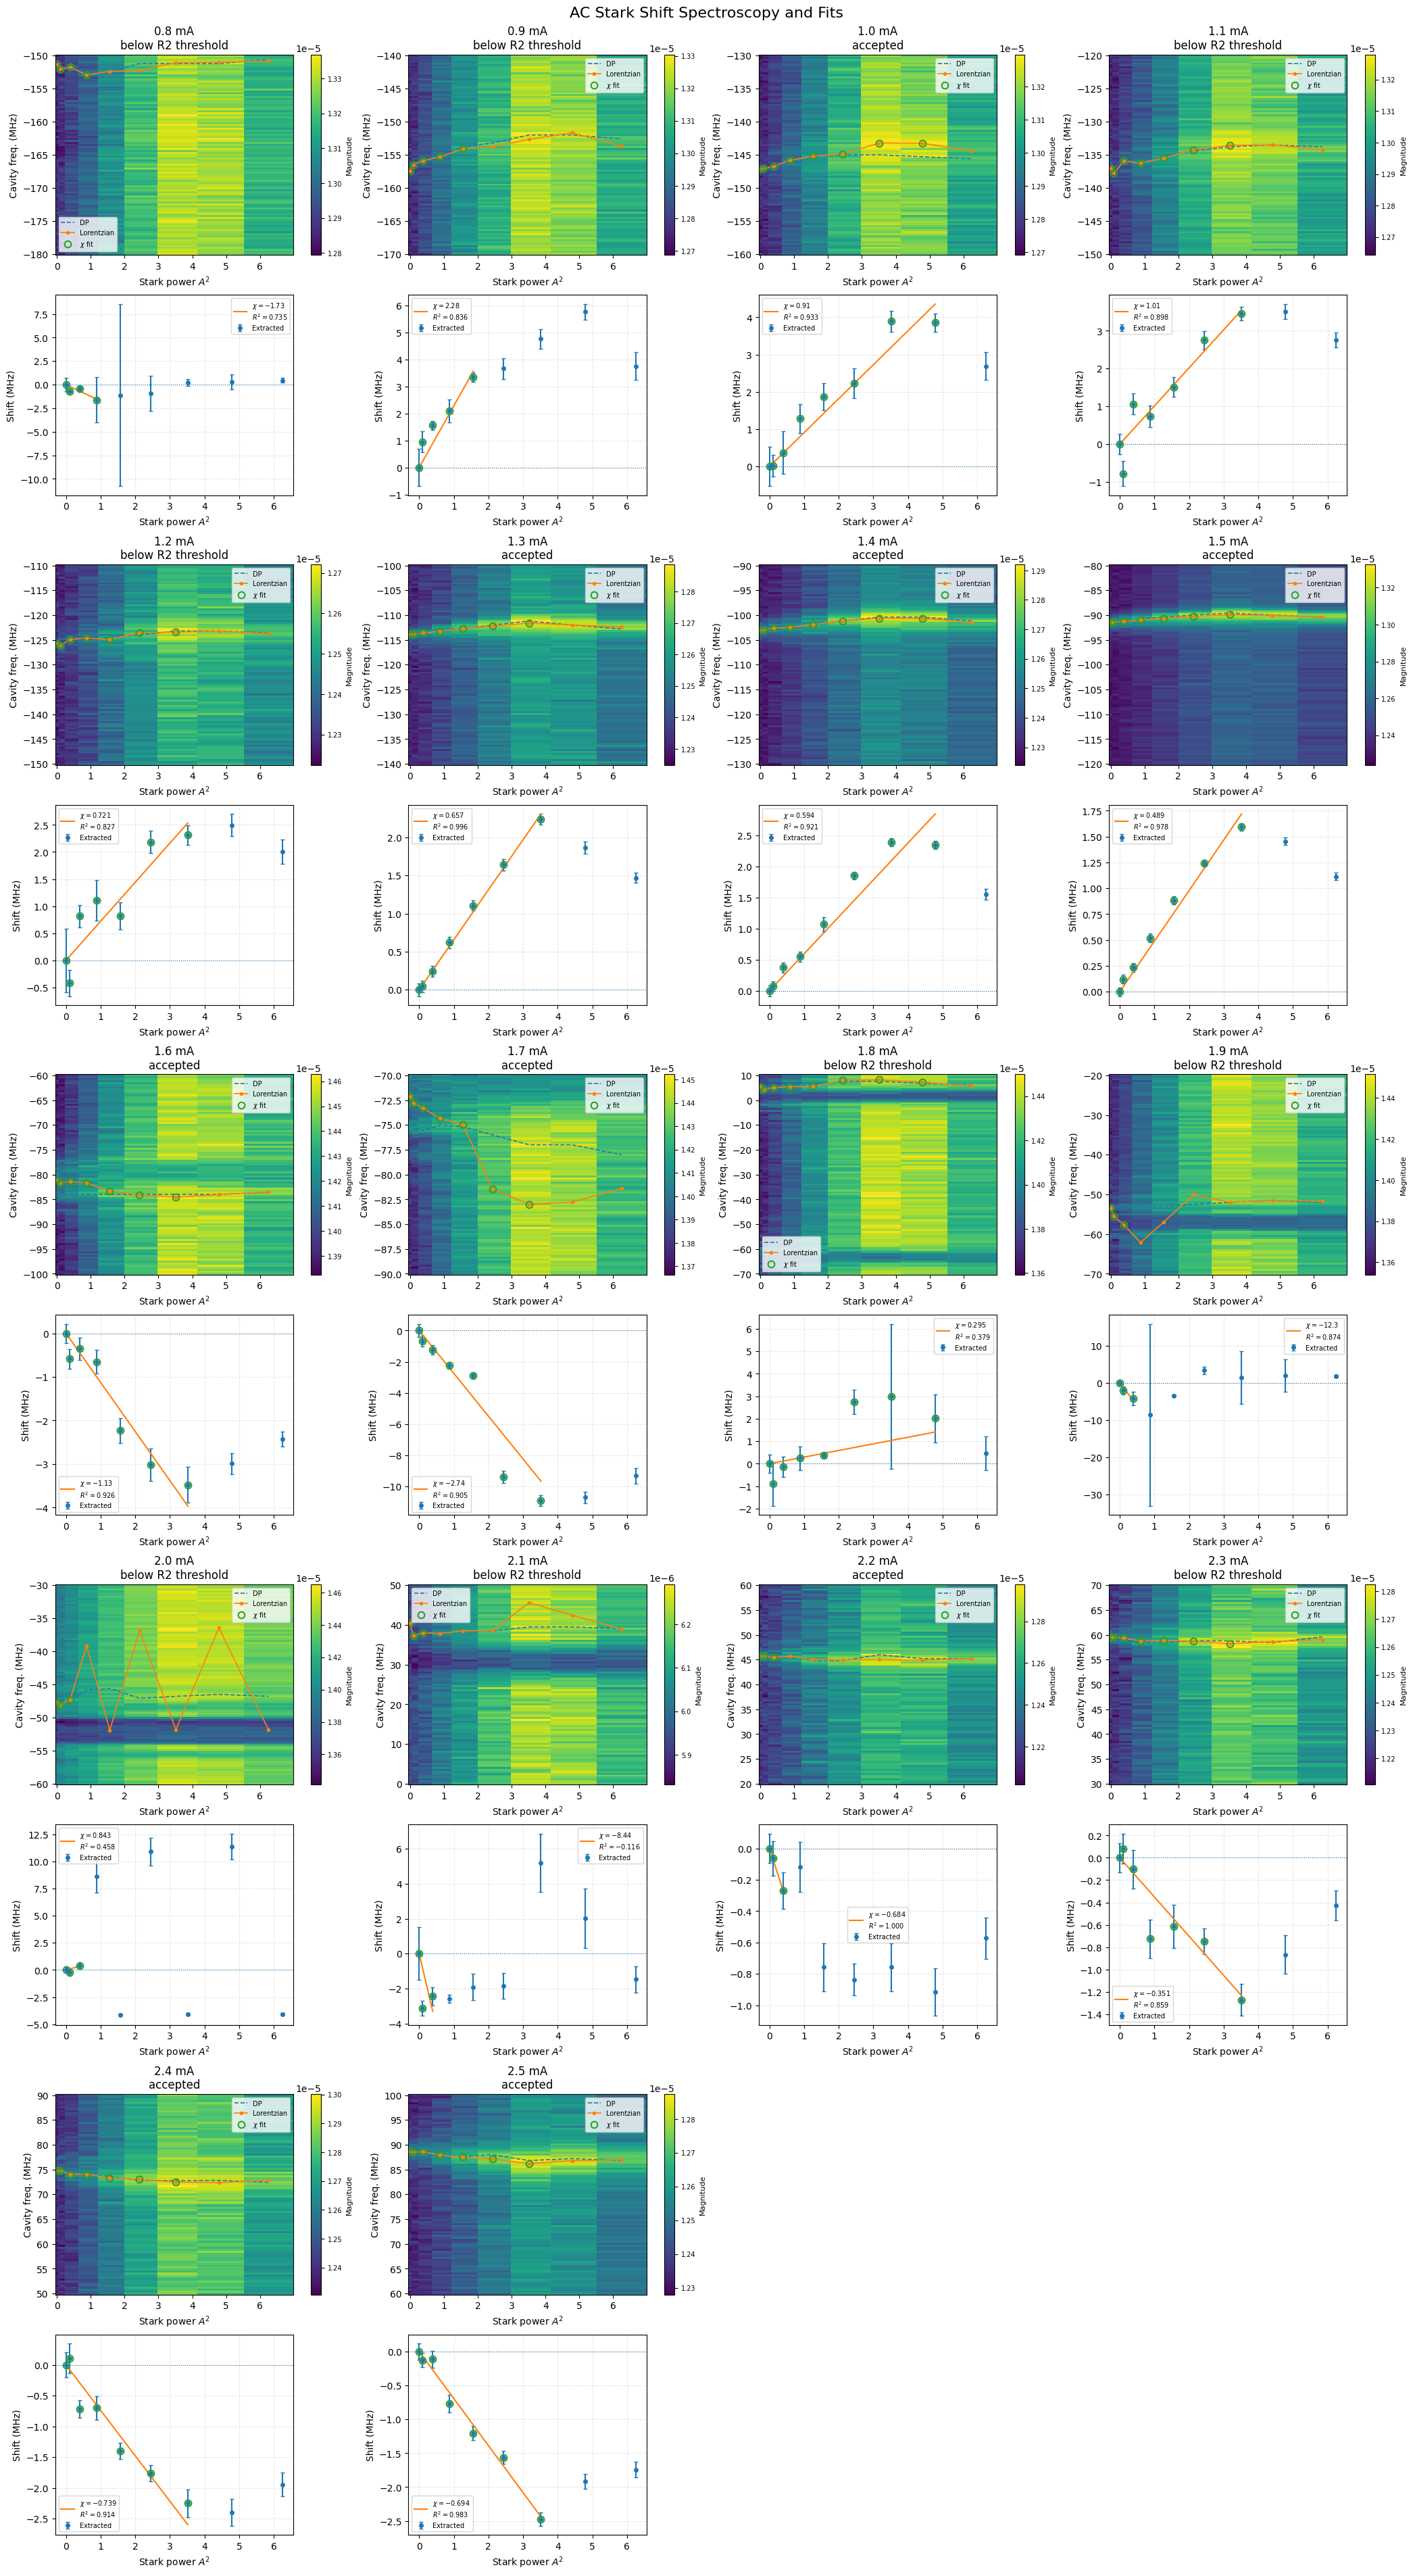

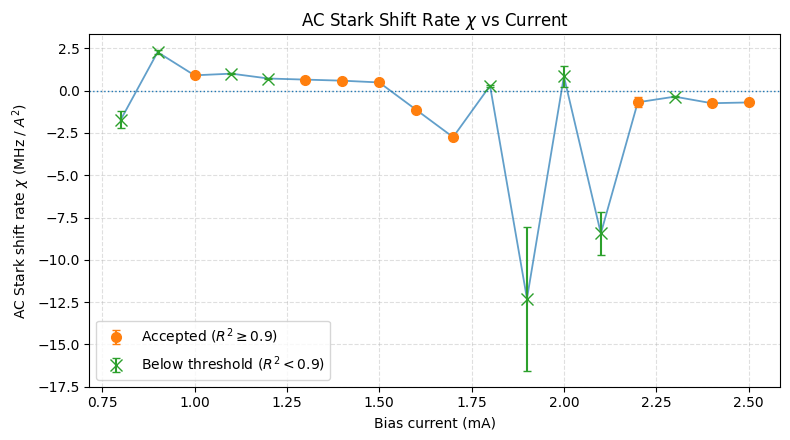


FINAL RESULTS
 Current             chi       chi_err        R2     N    accepted       SNR    peak
    0.80        -1.72797        0.4997    0.7354     4       False      5.36   False
    0.90         2.28136        0.1054    0.8361     5       False      5.13   False
    1.00        0.909893       0.04116    0.9330     8        True      5.81   False
    1.10         1.00889       0.04315    0.8980     7       False      5.40    True
    1.20        0.721393       0.04166    0.8265     7       False      4.23    True
    1.30         0.65651       0.01494    0.9965     7        True      9.14    True
    1.40        0.593768      0.009407    0.9211     8        True      9.03    True
    1.50        0.488918      0.007596    0.9780     7        True     15.55    True
    1.60        -1.12715        0.0787    0.9262     7        True      5.87    True
    1.70        -2.74494       0.06229    0.9053     7        True      4.41    True
    1.80        0.294503       0.05092    0.3787  

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# ==========================================================
# SETTINGS
# ==========================================================

SNR_MIN = 3.5
R2_MIN = 0.90
MAX_SHIFT_MHZ = 50.0
MIN_LINEAR_POINTS = 3
DP_LAMBDA = 0.4


# ==========================================================
# LORENTZIAN
# ==========================================================

def lorentzian(f, f0, gamma, amp, offset):
    return offset + amp * (
        gamma**2
        / ((f - f0)**2 + gamma**2)
    )


# ==========================================================
# ROBUST SNR
# ==========================================================

def robust_snr(z):

    med = np.median(z)

    mad = (
        np.median(
            np.abs(z - med)
        )
        * 1.4826
    )

    if mad == 0:
        return np.inf

    return (
        np.max(z) - np.min(z)
    ) / mad


# ==========================================================
# DP RIDGE TRACKING
# ==========================================================

def dp_ridge_track(
    f_axis,
    Z_slice,
    lam=DP_LAMBDA,
):

    n_freq, n_power = Z_slice.shape

    med = np.median(
        Z_slice,
        axis=0,
        keepdims=True,
    )

    mad = (
        np.median(
            np.abs(
                Z_slice - med
            ),
            axis=0,
            keepdims=True,
        )
        * 1.4826
    )

    mad[mad == 0] = 1.0

    zscore = (
        Z_slice - med
    ) / mad

    # Track positive resonance feature
    cost = -zscore

    D = np.empty(
        (n_freq, n_power)
    )

    ptr = np.empty(
        (n_freq, n_power),
        dtype=int,
    )

    D[:, 0] = cost[:, 0]

    f_diff2 = (
        f_axis[:, None]
        - f_axis[None, :]
    ) ** 2

    for j in range(
        1,
        n_power,
    ):

        trans = (
            D[None, :, j - 1]
            + lam * f_diff2
        )

        ptr[:, j] = np.argmin(
            trans,
            axis=1,
        )

        D[:, j] = (
            cost[:, j]
            + trans[
                np.arange(n_freq),
                ptr[:, j],
            ]
        )

    path_idx = np.empty(
        n_power,
        dtype=int,
    )

    path_idx[-1] = np.argmin(
        D[:, -1]
    )

    for j in range(
        n_power - 1,
        0,
        -1,
    ):

        path_idx[j - 1] = ptr[
            path_idx[j],
            j,
        ]

    return f_axis[path_idx]


# ==========================================================
# LORENTZIAN FIT
# ==========================================================

def fit_lorentzian(
    f_axis,
    z,
    p0,
):

    f_lo = f_axis.min()
    f_hi = f_axis.max()

    span = (
        f_hi - f_lo
    )

    lower = [
        f_lo,
        1e-3,
        -np.inf,
        -np.inf,
    ]

    upper = [
        f_hi,
        span,
        np.inf,
        np.inf,
    ]

    p0 = np.clip(
        p0,
        [
            b + 1e-9
            for b in lower
        ],
        [
            b - 1e-9
            for b in upper
        ],
    )

    try:

        popt, pcov = curve_fit(
            lorentzian,
            f_axis,
            z,
            p0=p0,
            bounds=(
                lower,
                upper,
            ),
            maxfev=4000,
        )

        return popt, pcov

    except Exception:
        return None


# ==========================================================
# REAL PEAK CHECK
# ==========================================================

def has_real_peak(
    z,
    min_width=2,
    z_thresh=2.0,
):

    med = np.median(z)

    mad = (
        np.median(
            np.abs(z - med)
        )
        * 1.4826
    )

    if mad == 0:
        return False

    zscore = (
        z - med
    ) / mad

    i = np.argmax(
        zscore
    )

    half = (
        zscore[i] / 2
    )

    above = (
        zscore
        > max(
            half,
            z_thresh / 2,
        )
    )

    lo = i

    while (
        lo > 0
        and above[lo - 1]
    ):
        lo -= 1

    hi = i

    while (
        hi < len(above) - 1
        and above[hi + 1]
    ):
        hi += 1

    return (
        hi - lo + 1
    ) >= min_width


# ==========================================================
# MAIN
# ==========================================================

def main():

    # ======================================================
    # LOAD DATA
    # ======================================================

    data_path = (
        r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot"
        r"\data_plot_data"
        r"\CavitySpec_stark_shift_2D_current_0.8mA_to_2.5mA.npz"
    )

    data = np.load(
        data_path
    )

    Z = data["Z"]

    cav_freq = data[
        "cavity_frequency"
    ]

    stark_ampx = data[
        "stark_ampx"
    ]

    current_mA = data[
        "current_mA"
    ]

    print(
        "Z shape:",
        Z.shape,
    )

    print(
        "cavity_frequency shape:",
        cav_freq.shape,
    )

    print(
        "stark_ampx shape:",
        stark_ampx.shape,
    )

    print(
        "current [mA]:",
        current_mA,
    )


    # ======================================================
    # RESULTS
    # ======================================================

    summary = []
    plot_results = []


    # ======================================================
    # LOOP OVER CURRENT
    # ======================================================

    for idx in range(
        len(current_mA)
    ):

        current = (
            current_mA[idx]
        )

        print()
        print(
            "=" * 60
        )

        print(
            f"Current = {current:.2f} mA"
        )


        # ==================================================
        # DATA
        # ==================================================

        f_axis = (
            cav_freq[idx]
            / 1e6
        )

        stark_amps = (
            stark_ampx[idx]
        )

        power = (
            stark_amps ** 2
        )

        Z_slice = (
            Z[idx]
        )

        z0 = (
            Z_slice[:, 0]
        )


        # ==================================================
        # INITIAL QUALITY CHECK
        # ==================================================

        snr = robust_snr(
            z0
        )

        peak_ok = has_real_peak(
            z0
        )

        print(
            f"SNR = {snr:.2f}"
        )

        print(
            f"peak check = {peak_ok}"
        )


        # We do NOT immediately remove the current
        # from the final summary plot.
        #
        # We still attempt fitting.


        # ==================================================
        # DP RIDGE
        # ==================================================

        f0_dp = dp_ridge_track(
            f_axis,
            Z_slice,
            lam=DP_LAMBDA,
        )


        # ==================================================
        # LORENTZIAN FIT AT EACH POWER
        # ==================================================

        n_power = len(
            stark_amps
        )

        f0_fits = np.full(
            n_power,
            np.nan,
        )

        f0_errs = np.full(
            n_power,
            np.nan,
        )

        gamma_fits = np.full(
            n_power,
            np.nan,
        )

        gamma_guess = 1.5


        for j in range(
            n_power
        ):

            zj = (
                Z_slice[:, j]
            )

            amp_guess = (
                np.max(zj)
                - np.min(zj)
            )

            offset_guess = (
                np.min(zj)
            )

            p0 = [
                f0_dp[j],
                gamma_guess,
                amp_guess,
                offset_guess,
            ]

            fit_j = fit_lorentzian(
                f_axis,
                zj,
                p0,
            )

            if fit_j is None:

                print(
                    f"fit failed at "
                    f"power index {j}"
                )

                continue

            popt, pcov = (
                fit_j
            )

            perr = np.sqrt(
                np.diag(
                    pcov
                )
            )

            f0_fits[j] = (
                popt[0]
            )

            f0_errs[j] = (
                perr[0]
            )

            gamma_fits[j] = (
                popt[1]
            )

            gamma_guess = max(
                popt[1],
                1e-3,
            )


        # ==================================================
        # VALID FITS
        # ==================================================

        valid = (
            np.isfinite(
                f0_fits
            )
            &
            np.isfinite(
                f0_errs
            )
        )

        n_valid = np.sum(
            valid
        )

        print(
            f"Valid fits = "
            f"{n_valid}/{n_power}"
        )


        # ==================================================
        # IF TOO FEW FITS, STORE IT AS INVALID
        # ==================================================

        if (
            n_valid
            < MIN_LINEAR_POINTS
        ):

            print(
                "Not enough valid fits."
            )

            summary.append(
                {
                    "current_mA":
                        current,

                    "chi":
                        np.nan,

                    "chi_err":
                        np.nan,

                    "n_points":
                        0,

                    "r2":
                        np.nan,

                    "accepted":
                        False,

                    "snr":
                        snr,

                    "peak_ok":
                        peak_ok,
                }
            )

            continue


        # ==================================================
        # FREQUENCY SHIFT
        # ==================================================

        first_valid = np.where(
            valid
        )[0][0]

        f_ref = (
            f0_fits[
                first_valid
            ]
        )

        shifts = (
            f0_fits
            - f_ref
        )


        # ==================================================
        # SEARCH LOW-POWER FIT RANGE
        #
        # accepted_*:
        # largest range satisfying R2 >= R2_MIN
        #
        # fallback_*:
        # best available range even if R2 fails
        # ==================================================

        accepted_k = 0
        accepted_chi = np.nan
        accepted_chi_err = np.nan
        accepted_r2 = -np.inf

        fallback_k = 0
        fallback_chi = np.nan
        fallback_chi_err = np.nan
        fallback_r2 = -np.inf


        for k in range(
            MIN_LINEAR_POINTS,
            len(power) + 1,
        ):

            # Must be continuous from lowest power
            if not np.all(
                valid[:k]
            ):
                break

            p_sub = (
                power[:k]
            )

            s_sub = (
                shifts[:k]
            )

            e_sub = (
                f0_errs[:k]
            )

            # Fit-artifact / bifurcation cutoff
            if np.any(
                np.abs(
                    s_sub
                )
                > MAX_SHIFT_MHZ
            ):
                break


            # ==============================================
            # WEIGHTED LINEAR FIT THROUGH ORIGIN
            #
            # shift = chi * power
            # ==============================================

            w = (
                1.0
                /
                np.clip(
                    e_sub,
                    1e-6,
                    None,
                ) ** 2
            )

            denominator = np.sum(
                w
                * p_sub**2
            )

            if denominator <= 0:
                continue

            chi = (
                np.sum(
                    w
                    * p_sub
                    * s_sub
                )
                /
                denominator
            )

            chi_err = (
                1.0
                /
                np.sqrt(
                    denominator
                )
            )

            y_pred = (
                chi
                * p_sub
            )

            ss_res = np.sum(
                (
                    s_sub
                    - y_pred
                ) ** 2
            )

            ss_tot = np.sum(
                (
                    s_sub
                    - np.mean(
                        s_sub
                    )
                ) ** 2
            )

            if ss_tot > 0:

                r2 = (
                    1.0
                    - ss_res
                    / ss_tot
                )

            else:

                r2 = 0.0


            # ==============================================
            # FALLBACK RESULT
            #
            # Keep result with highest R2.
            # If same R2, prefer more points.
            # ==============================================

            if (
                r2 > fallback_r2
                or
                (
                    np.isclose(
                        r2,
                        fallback_r2,
                    )
                    and
                    k > fallback_k
                )
            ):

                fallback_k = (
                    k
                )

                fallback_chi = (
                    chi
                )

                fallback_chi_err = (
                    chi_err
                )

                fallback_r2 = (
                    r2
                )


            # ==============================================
            # ACCEPTED RESULT
            #
            # Among fits passing R2_MIN,
            # prefer largest contiguous range.
            # ==============================================

            if (
                r2 >= R2_MIN
                and
                k >= accepted_k
            ):

                accepted_k = (
                    k
                )

                accepted_chi = (
                    chi
                )

                accepted_chi_err = (
                    chi_err
                )

                accepted_r2 = (
                    r2
                )


        # ==================================================
        # CHOOSE ACCEPTED OR FALLBACK RESULT
        # ==================================================

        if (
            accepted_k
            >= MIN_LINEAR_POINTS
        ):

            best_k = (
                accepted_k
            )

            best_chi = (
                accepted_chi
            )

            best_chi_err = (
                accepted_chi_err
            )

            best_r2 = (
                accepted_r2
            )

            accepted = True

        else:

            best_k = (
                fallback_k
            )

            best_chi = (
                fallback_chi
            )

            best_chi_err = (
                fallback_chi_err
            )

            best_r2 = (
                fallback_r2
            )

            accepted = False


        # ==================================================
        # PRINT RESULT
        # ==================================================

        print(
            f"chi = "
            f"{best_chi:.6g} MHz/A^2"
        )

        print(
            f"R2 = "
            f"{best_r2:.4f}"
        )

        print(
            f"N = "
            f"{best_k}"
        )

        print(
            f"accepted = "
            f"{accepted}"
        )


        # ==================================================
        # STORE SUMMARY
        # ==================================================

        summary.append(
            {
                "current_mA":
                    current,

                "chi":
                    best_chi,

                "chi_err":
                    best_chi_err,

                "n_points":
                    best_k,

                "r2":
                    best_r2,

                "accepted":
                    accepted,

                "snr":
                    snr,

                "peak_ok":
                    peak_ok,
            }
        )


        # ==================================================
        # STORE SUBPLOT DATA
        # ==================================================

        plot_results.append(
            {
                "current":
                    current,

                "power":
                    power.copy(),

                "f_axis":
                    f_axis.copy(),

                "Z_slice":
                    Z_slice.copy(),

                "f0_dp":
                    f0_dp.copy(),

                "f0_fits":
                    f0_fits.copy(),

                "f0_errs":
                    f0_errs.copy(),

                "valid":
                    valid.copy(),

                "shifts":
                    shifts.copy(),

                "best_k":
                    best_k,

                "best_chi":
                    best_chi,

                "best_chi_err":
                    best_chi_err,

                "best_r2":
                    best_r2,

                "accepted":
                    accepted,
            }
        )


    # ==========================================================
    # 2D + FIT SUBPLOTS
    # ==========================================================

    nplots = len(
        plot_results
    )

    if nplots > 0:

        ncols = 4

        ngroups = int(
            np.ceil(
                nplots / ncols
            )
        )

        nrows = (
            2 * ngroups
        )

        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(
                5.2 * ncols,
                3.8 * nrows,
            ),
            constrained_layout=True,
        )

        axes = np.asarray(
            axes
        )

        if axes.ndim == 1:

            axes = axes.reshape(
                nrows,
                ncols,
            )


        # ======================================================
        # LOOP THROUGH STORED RESULTS
        # ======================================================

        for i, result in enumerate(
            plot_results
        ):

            group = (
                i // ncols
            )

            col = (
                i % ncols
            )

            row_2d = (
                2 * group
            )

            row_fit = (
                row_2d + 1
            )

            ax2d = axes[
                row_2d,
                col,
            ]

            axfit = axes[
                row_fit,
                col,
            ]


            # ==============================================
            # GET DATA
            # ==============================================

            current = (
                result["current"]
            )

            power = (
                result["power"]
            )

            f_axis = (
                result["f_axis"]
            )

            Z_slice = (
                result["Z_slice"]
            )

            f0_dp = (
                result["f0_dp"]
            )

            f0_fits = (
                result["f0_fits"]
            )

            f0_errs = (
                result["f0_errs"]
            )

            valid = (
                result["valid"]
            )

            shifts = (
                result["shifts"]
            )

            best_k = (
                result["best_k"]
            )

            best_chi = (
                result["best_chi"]
            )

            best_r2 = (
                result["best_r2"]
            )

            accepted = (
                result["accepted"]
            )


            # ==============================================
            # TOP: 2D SPECTROSCOPY
            # ==============================================

            pcm = ax2d.pcolormesh(
                power,
                f_axis,
                Z_slice,
                shading="auto",
            )

            ax2d.plot(
                power,
                f0_dp,
                "--",
                linewidth=1.2,
                label="DP",
            )

            ax2d.plot(
                power[valid],
                f0_fits[valid],
                "o-",
                markersize=3,
                linewidth=1.2,
                label="Lorentzian",
            )


            # Highlight points used for chi
            if (
                best_k
                >= MIN_LINEAR_POINTS
            ):

                ax2d.plot(
                    power[:best_k],
                    f0_fits[:best_k],
                    "o",
                    markersize=7,
                    markerfacecolor="none",
                    markeredgewidth=1.5,
                    label=r"$\chi$ fit",
                )


            # Accepted / rejected title
            if accepted:

                title_status = (
                    "accepted"
                )

            else:

                title_status = (
                    "below R2 threshold"
                )


            ax2d.set_title(
                f"{current:.1f} mA\n"
                f"{title_status}"
            )

            ax2d.set_xlabel(
                r"Stark power $A^2$"
            )

            ax2d.set_ylabel(
                "Cavity freq. (MHz)"
            )

            ax2d.legend(
                fontsize=7,
                loc="best",
            )

            cbar = fig.colorbar(
                pcm,
                ax=ax2d,
                pad=0.01,
            )

            cbar.set_label(
                "Magnitude",
                fontsize=8,
            )

            cbar.ax.tick_params(
                labelsize=7
            )


            # ==============================================
            # BOTTOM: SHIFT VS POWER
            # ==============================================

            axfit.errorbar(
                power[valid],
                shifts[valid],
                yerr=f0_errs[valid],
                fmt="o",
                markersize=4,
                capsize=2,
                label="Extracted",
            )


            # ==============================================
            # LINEAR FIT
            # ==============================================

            if (
                best_k
                >= MIN_LINEAR_POINTS
                and
                np.isfinite(
                    best_chi
                )
            ):

                p_fit = np.linspace(
                    0,
                    power[
                        best_k - 1
                    ],
                    200,
                )

                axfit.plot(
                    p_fit,
                    best_chi
                    * p_fit,
                    "-",
                    linewidth=1.5,
                    label=(
                        rf"$\chi="
                        rf"{best_chi:.3g}$"
                        "\n"
                        rf"$R^2="
                        rf"{best_r2:.3f}$"
                    ),
                )

                axfit.plot(
                    power[:best_k],
                    shifts[:best_k],
                    "o",
                    markersize=7,
                    markerfacecolor="none",
                    markeredgewidth=1.5,
                )


            axfit.axhline(
                0,
                linestyle=":",
                linewidth=0.8,
            )

            axfit.set_xlabel(
                r"Stark power $A^2$"
            )

            axfit.set_ylabel(
                "Shift (MHz)"
            )

            axfit.grid(
                True,
                linestyle="--",
                alpha=0.3,
            )

            axfit.legend(
                fontsize=7,
                loc="best",
            )


        # ==================================================
        # HIDE UNUSED PANELS
        # ==================================================

        total_slots = (
            ngroups
            * ncols
        )

        for i in range(
            nplots,
            total_slots,
        ):

            group = (
                i // ncols
            )

            col = (
                i % ncols
            )

            axes[
                2 * group,
                col,
            ].set_visible(
                False
            )

            axes[
                2 * group + 1,
                col,
            ].set_visible(
                False
            )


        fig.suptitle(
            "AC Stark Shift Spectroscopy and Fits",
            fontsize=16,
        )

        plt.show()


    # ==========================================================
    # FINAL CHI VS CURRENT
    # ==========================================================

    summary.sort(
        key=lambda x:
        x["current_mA"]
    )


    currents = np.array([
        r["current_mA"]
        for r in summary
    ])

    chis = np.array([
        r["chi"]
        for r in summary
    ])

    chi_errs = np.array([
        r["chi_err"]
        for r in summary
    ])

    accepted_array = np.array([
        r["accepted"]
        for r in summary
    ])

    finite = (
        np.isfinite(chis)
        &
        np.isfinite(chi_errs)
    )


    # ==========================================================
    # PLOT
    # ==========================================================

    fig, ax = plt.subplots(
        figsize=(8, 4.5)
    )


    # ----------------------------------------------------------
    # Connect every fitted point
    # ----------------------------------------------------------

    ax.plot(
        currents[finite],
        chis[finite],
        "-",
        linewidth=1.3,
        alpha=0.7,
    )


    # ----------------------------------------------------------
    # Accepted fits
    # ----------------------------------------------------------

    good = (
        finite
        &
        accepted_array
    )

    ax.errorbar(
        currents[good],
        chis[good],
        yerr=chi_errs[good],
        fmt="o",
        markersize=7,
        capsize=3,
        label=(
            rf"Accepted "
            rf"($R^2 \geq {R2_MIN}$)"
        ),
    )


    # ----------------------------------------------------------
    # Fits below R2 threshold
    # ----------------------------------------------------------

    bad = (
        finite
        &
        ~accepted_array
    )

    ax.errorbar(
        currents[bad],
        chis[bad],
        yerr=chi_errs[bad],
        fmt="x",
        markersize=8,
        capsize=3,
        label=(
            rf"Below threshold "
            rf"($R^2 < {R2_MIN}$)"
        ),
    )


    ax.set_xlabel(
        "Bias current (mA)"
    )

    ax.set_ylabel(
        r"AC Stark shift rate "
        r"$\chi$ (MHz / $A^2$)"
    )

    ax.axhline(
        0,
        linestyle=":",
        linewidth=1,
    )

    ax.grid(
        True,
        linestyle="--",
        alpha=0.4,
    )

    ax.legend()

    ax.set_title(
        r"AC Stark Shift Rate "
        r"$\chi$ vs Current"
    )

    plt.tight_layout()

    plt.show()


    # ==========================================================
    # PRINT FULL SUMMARY
    # ==========================================================

    print()
    print(
        "=" * 100
    )

    print(
        "FINAL RESULTS"
    )

    print(
        "=" * 100
    )

    print(
        f"{'Current':>8}  "
        f"{'chi':>14}  "
        f"{'chi_err':>12}  "
        f"{'R2':>8}  "
        f"{'N':>4}  "
        f"{'accepted':>10}  "
        f"{'SNR':>8}  "
        f"{'peak':>6}"
    )


    for r in summary:

        print(
            f"{r['current_mA']:8.2f}  "
            f"{r['chi']:14.6g}  "
            f"{r['chi_err']:12.4g}  "
            f"{r['r2']:8.4f}  "
            f"{r['n_points']:4d}  "
            f"{str(r['accepted']):>10}  "
            f"{r['snr']:8.2f}  "
            f"{str(r['peak_ok']):>6}"
        )


    return summary


# ==========================================================
# RUN
# ==========================================================

if __name__ == "__main__":

    results = main()

In [11]:
def main():

    data_path = (
        r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot"
        r"\data_plot_data"
        r"\CavitySpec_stark_shift_2D_current_0.8mA_to_2.5mA.npz"
    )

    data = np.load(data_path)

    Z = data["Z"]
    cav_freq = data["cavity_frequency"]
    stark_ampx = data["stark_ampx"]

    # NEW NPZ key
    current_mA = data["current_mA"]

    print("Z shape:", Z.shape)
    print("cavity_frequency shape:", cav_freq.shape)
    print("stark_ampx shape:", stark_ampx.shape)
    print("current [mA]:", current_mA)

    dynamic_summary = []


    # ==========================================================
    # LOOP OVER CURRENT
    # ==========================================================

    for idx in range(len(current_mA)):

        current = current_mA[idx]

        f_axis = cav_freq[idx] / 1e6       # Hz -> MHz
        stark_amps = stark_ampx[idx]
        power = stark_amps ** 2

        Z_slice = Z[idx]

        z0 = Z_slice[:, 0]


        # ======================================================
        # CHECK DATA QUALITY
        # ======================================================

        if robust_snr(z0) < SNR_MIN:
            print(
                f"{current:.2f} mA: rejected, "
                f"SNR = {robust_snr(z0):.2f}"
            )
            continue

        if not has_real_peak(z0):
            print(
                f"{current:.2f} mA: rejected, "
                "no real peak"
            )
            continue


        # ======================================================
        # DP RIDGE TRACK
        # ======================================================

        f0_dp = dp_ridge_track(
            f_axis,
            Z_slice,
            lam=DP_LAMBDA,
        )


        # ======================================================
        # LORENTZIAN FIT AT EACH STARK POWER
        # ======================================================

        f0_fits = np.full(
            len(stark_amps),
            np.nan,
        )

        f0_errs = np.full(
            len(stark_amps),
            np.nan,
        )

        gamma_fits = np.full(
            len(stark_amps),
            np.nan,
        )

        gamma_guess = 1.5  # MHz


        for j in range(len(stark_amps)):

            zj = Z_slice[:, j]

            amp_guess = (
                np.max(zj)
                - np.min(zj)
            )

            offset_guess = np.min(zj)

            p0 = [
                f0_dp[j],
                gamma_guess,
                amp_guess,
                offset_guess,
            ]


            fit_j = fit_lorentzian(
                f_axis,
                zj,
                p0,
            )


            if fit_j is None:
                continue


            popt, pcov = fit_j

            perr = np.sqrt(
                np.diag(pcov)
            )


            f0_fits[j] = popt[0]
            f0_errs[j] = perr[0]
            gamma_fits[j] = popt[1]

            gamma_guess = max(
                popt[1],
                1e-3,
            )


        # ======================================================
        # ONLY USE SUCCESSFUL FITS
        # ======================================================

        valid = (
            np.isfinite(f0_fits)
            & np.isfinite(f0_errs)
        )

        if np.sum(valid) < MIN_LINEAR_POINTS:
            print(
                f"{current:.2f} mA: "
                "not enough Lorentzian fits"
            )
            continue


        # Reference = first valid fitted frequency
        first_valid = np.where(valid)[0][0]

        f_ref = f0_fits[first_valid]

        shifts = (
            f0_fits
            - f_ref
        )


        # ======================================================
        # FIND LOW-POWER LINEAR REGION
        # ======================================================

        best_k = 0
        best_chi = np.nan
        best_chi_err = np.nan
        best_r2 = -1


        # We assume low-power points begin at j = 0
        for k in range(
            MIN_LINEAR_POINTS,
            len(power) + 1,
        ):

            if not np.all(valid[:k]):
                break

            p_sub = power[:k]
            s_sub = shifts[:k]
            e_sub = f0_errs[:k]


            # reject obviously bad fitted region
            if np.any(
                np.abs(s_sub) > MAX_SHIFT_MHZ
            ):
                break


            w = (
                1.0
                / np.clip(
                    e_sub,
                    1e-6,
                    None,
                ) ** 2
            )


            # weighted fit through origin:
            #
            # shift = chi * power
            #
            chi = (
                np.sum(
                    w * p_sub * s_sub
                )
                /
                np.sum(
                    w * p_sub ** 2
                )
            )


            chi_err = (
                1.0
                /
                np.sqrt(
                    np.sum(
                        w * p_sub ** 2
                    )
                )
            )


            y_pred = (
                chi * p_sub
            )


            ss_res = np.sum(
                (s_sub - y_pred) ** 2
            )

            ss_tot = np.sum(
                (
                    s_sub
                    - np.mean(s_sub)
                ) ** 2
            )


            if ss_tot > 0:
                r2 = (
                    1
                    - ss_res / ss_tot
                )
            else:
                r2 = 0


            if (
                r2 >= R2_MIN
                and k >= best_k
            ):

                best_k = k
                best_chi = chi
                best_chi_err = chi_err
                best_r2 = r2


        # ======================================================
        # SAVE RESULT
        # ======================================================

        if best_k >= MIN_LINEAR_POINTS:

            dynamic_summary.append(
                {
                    "current_mA": current,
                    "chi": best_chi,
                    "chi_err": best_chi_err,
                    "n_points": best_k,
                    "r2": best_r2,
                }
            )


        # ======================================================
        # 2D DATA + FIT OVERLAY
        # ======================================================

        fig, ax = plt.subplots(
            figsize=(7, 5)
        )


        pcm = ax.pcolormesh(
            power,
            f_axis,
            Z_slice,
            shading="auto",
        )


        # ------------------------------------------------------
        # DP ridge
        # ------------------------------------------------------

        ax.plot(
            power,
            f0_dp,
            "--",
            linewidth=1.5,
            label="DP ridge",
        )


        # ------------------------------------------------------
        # Lorentzian fitted resonance
        # ------------------------------------------------------

        ax.plot(
            power[valid],
            f0_fits[valid],
            "o-",
            markersize=4,
            linewidth=1.5,
            label="Lorentzian fit",
        )


        # ------------------------------------------------------
        # Highlight points used for chi fit
        # ------------------------------------------------------

        if best_k >= MIN_LINEAR_POINTS:

            ax.plot(
                power[:best_k],
                f0_fits[:best_k],
                "o",
                markersize=8,
                markerfacecolor="none",
                markeredgewidth=2,
                label="Used for χ fit",
            )


        # ------------------------------------------------------
        # Labels
        # ------------------------------------------------------

        ax.set_xlabel(
            r"Stark drive power $A^2$"
        )

        ax.set_ylabel(
            "Cavity frequency (MHz)"
        )


        if best_k >= MIN_LINEAR_POINTS:

            ax.set_title(
                f"Current = {current:.2f} mA\n"
                f"χ = {best_chi:.4g} MHz/$A^2$, "
                f"$R^2$ = {best_r2:.3f}"
            )

        else:

            ax.set_title(
                f"Current = {current:.2f} mA\n"
                "No accepted linear Stark fit"
            )


        ax.legend()

        cbar = fig.colorbar(
            pcm,
            ax=ax,
        )

        cbar.set_label(
            "Mean magnitude"
        )


        plt.tight_layout()
        plt.show()


        # ======================================================
        # ALSO SHOW SHIFT VS POWER + LINEAR FIT
        # ======================================================

        fig, ax = plt.subplots(
            figsize=(6, 4)
        )


        ax.errorbar(
            power[valid],
            shifts[valid],
            yerr=f0_errs[valid],
            fmt="o",
            capsize=3,
            label="Lorentzian extracted shift",
        )


        if best_k >= MIN_LINEAR_POINTS:

            p_fit = np.linspace(
                0,
                power[best_k - 1],
                200,
            )

            ax.plot(
                p_fit,
                best_chi * p_fit,
                "-",
                linewidth=2,
                label=(
                    f"Linear fit\n"
                    f"χ = {best_chi:.4g} MHz/$A^2$\n"
                    f"$R^2$ = {best_r2:.3f}"
                ),
            )


        ax.axhline(
            0,
            linestyle=":",
            linewidth=1,
        )

        ax.set_xlabel(
            r"Stark drive power $A^2$"
        )

        ax.set_ylabel(
            "Cavity frequency shift (MHz)"
        )

        ax.set_title(
            f"AC Stark shift, current = {current:.2f} mA"
        )

        ax.grid(
            True,
            linestyle="--",
            alpha=0.4,
        )

        ax.legend()

        plt.tight_layout()
        plt.show()


    # ==========================================================
    # SUMMARY χ VS CURRENT
    # ==========================================================

    if not dynamic_summary:

        raise RuntimeError(
            "No current points passed "
            "the SNR/linearity criteria."
        )


    dynamic_summary.sort(
        key=lambda x: x["current_mA"]
    )


    currents = np.array([
        r["current_mA"]
        for r in dynamic_summary
    ])

    chis = np.array([
        r["chi"]
        for r in dynamic_summary
    ])

    chi_errs = np.array([
        r["chi_err"]
        for r in dynamic_summary
    ])


    # ==========================================================
    # PLOT χ VS CURRENT
    # ==========================================================

    fig, ax = plt.subplots(
        figsize=(8, 4.5)
    )


    ax.errorbar(
        currents,
        chis,
        yerr=chi_errs,
        fmt="o-",
        linewidth=2,
        markersize=7,
        capsize=3,
    )


    ax.set_xlabel(
        "Bias current (mA)"
    )

    ax.set_ylabel(
        r"AC Stark shift rate $\chi$ (MHz / $A^2$)"
    )

    ax.axhline(
        0,
        linestyle=":",
        linewidth=1,
    )

    ax.grid(
        True,
        linestyle="--",
        alpha=0.5,
    )

    ax.set_title(
        r"AC Stark Shift Rate $\chi$ vs Current"
    )

    plt.tight_layout()
    plt.show()


    return dynamic_summary

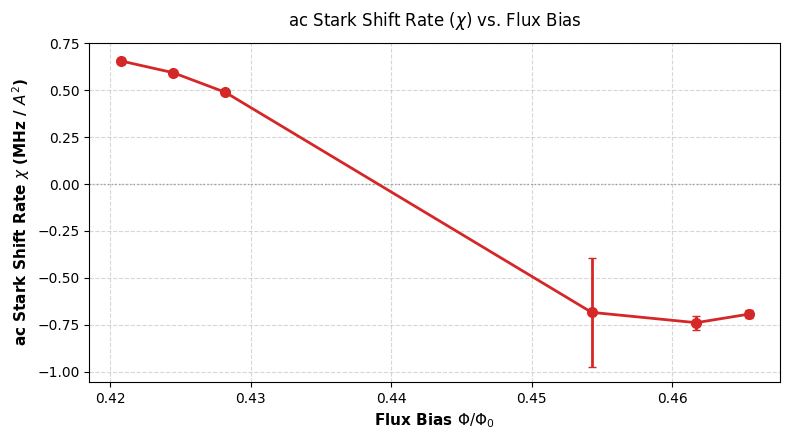

In [ ]:
"""
AC Stark shift (chi) extraction vs. flux bias, plotted in flux-quanta units.

Pipeline per flux point:
  1. DP ridge-track the cavity resonance across the whole power sweep at once
     (globally consistent, smooth f0(power) path -> robust against a single
     bad/noisy frame derailing the fit chain).
  2. Use the DP path as the f0 seed for a per-power-step bounded Lorentzian
     fit (gamma/amp/offset estimated fresh from local data each step).
  3. shift(power) = f0_fit(power) - f0_fit(zero power).
  4. Find the largest contiguous low-power range where shift(power) is linear
     in power (R^2 >= threshold); fit chi = shift/power through the origin
     (weighted by each point's fit uncertainty).
  5. Convert flux (bias current, mA) -> flux quanta Phi/Phi0 and plot.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---------------------------------------------------------------- settings
SNR_MIN = 3.5                # minimum peak SNR to attempt a flux point
R2_MIN = 0.90                 # minimum R^2 to accept the linear (chi) regime
MAX_SHIFT_MHZ = 50.0          # discard points beyond this as fit artifacts
MIN_LINEAR_POINTS = 3         # need at least this many points to trust chi
DP_LAMBDA = 0.4               # DP smoothness penalty weight (see dp_ridge_track)
I_PERIOD_MA = 26.857          # flux period, mA
I0_MA = -10.000               # current at Phi/Phi0 = 0, mA


def lorentzian(f, f0, gamma, amp, offset):
    return offset + amp * (gamma**2 / ((f - f0) ** 2 + gamma**2))


def robust_snr(z):
    """Peak-to-peak signal over a median-absolute-deviation noise estimate."""
    med = np.median(z)
    mad = np.median(np.abs(z - med)) * 1.4826  # -> sigma-equivalent
    if mad == 0:
        return np.inf
    return (np.max(z) - np.min(z)) / mad


def dp_ridge_track(f_axis, Z_slice, lam=DP_LAMBDA):
    """
    Globally-optimal smooth ridge (resonance-frequency path) across a
    frequency x power slice, via dynamic programming (Viterbi-style).

    Cost at each (frequency, power) node is based on a per-column z-score
    of the signal (so different power steps with different baseline/amp
    are comparable). Transition cost between adjacent power steps penalizes
    large frequency jumps, encoding the physical prior that the resonance
    moves smoothly with power.

    Parameters
    ----------
    f_axis : (n_freq,) array, frequency axis in MHz
    Z_slice : (n_freq, n_power) array, signal for this flux point
    lam : transition penalty weight (larger = smoother/stiffer path)

    Returns
    -------
    f0_path : (n_power,) array, tracked resonance frequency at each power
    """
    n_freq, n_power = Z_slice.shape

    med = np.median(Z_slice, axis=0, keepdims=True)
    mad = np.median(np.abs(Z_slice - med), axis=0, keepdims=True) * 1.4826
    mad[mad == 0] = 1.0
    zscore = (Z_slice - med) / mad
    cost = -zscore  # lower cost = stronger signal = more likely the peak

    D = np.empty((n_freq, n_power))
    ptr = np.empty((n_freq, n_power), dtype=int)
    D[:, 0] = cost[:, 0]

    # (n_freq, n_freq) matrix of squared frequency differences, reused every step
    f_diff2 = (f_axis[:, None] - f_axis[None, :]) ** 2

    for j in range(1, n_power):
        # trans[i, k] = cost of having come from freq index k at step j-1
        # to freq index i at step j
        trans = D[None, :, j - 1] + lam * f_diff2
        ptr[:, j] = np.argmin(trans, axis=1)
        D[:, j] = cost[:, j] + trans[np.arange(n_freq), ptr[:, j]]

    path_idx = np.empty(n_power, dtype=int)
    path_idx[-1] = np.argmin(D[:, -1])
    for j in range(n_power - 1, 0, -1):
        path_idx[j - 1] = ptr[path_idx[j], j]

    return f_axis[path_idx]


def fit_lorentzian(f_axis, z, p0):
    """Bounded Lorentzian fit; returns (popt, pcov) or None on failure."""
    f_lo, f_hi = f_axis.min(), f_axis.max()
    span = f_hi - f_lo
    lower = [f_lo, 1e-3, -np.inf, -np.inf]
    upper = [f_hi, span, np.inf, np.inf]
    p0 = np.clip(p0, [b + 1e-9 for b in lower], [b - 1e-9 for b in upper])
    try:
        popt, pcov = curve_fit(
            lorentzian, f_axis, z, p0=p0,
            bounds=(lower, upper), maxfev=4000,
        )
        return popt, pcov
    except Exception:
        return None

def has_real_peak(z, min_width=2, z_thresh=2.0):
    """
    Reject flux points whose "resonance" is really just a single noisy bin.

    robust_snr() only measures peak-height / MAD, which a lone noise spike
    can satisfy just as easily as a genuine Lorentzian dip/peak. A real
    cavity line is several bins wide (set by its linewidth); pure noise is
    not. This checks that the region around the max z-score is at least
    `min_width` contiguous bins above half-max (and above z_thresh/2), and
    rejects single-bin spikes.
    """
    med = np.median(z)
    mad = np.median(np.abs(z - med)) * 1.4826
    if mad == 0:
        return False
    zscore = (z - med) / mad
    i = np.argmax(zscore)
    half = zscore[i] / 2
    above = zscore > max(half, z_thresh / 2)
    lo = i
    while lo > 0 and above[lo - 1]:
        lo -= 1
    hi = i
    while hi < len(above) - 1 and above[hi + 1]:
        hi += 1
    return (hi - lo + 1) >= min_width


def main():
    data = np.load("CavitySpec_stark_shift_2D_flux_combined_3.npz")
    Z = data["Z"]
    cav_freq = data["cavity_frequency"]
    stark_ampx = data["stark_ampx"]
    flux = data["flux"]*1e3  # bias current, mA

    dynamic_summary = []

    for idx in range(len(flux)):
        f_axis = cav_freq[idx] / 1e6           # Hz -> MHz
        stark_amps = stark_ampx[idx]
        power = stark_amps ** 2
        z0 = Z[idx, :, 0]

        # before
        if robust_snr(z0) < SNR_MIN:
            continue

        # after
        if robust_snr(z0) < SNR_MIN or not has_real_peak(z0):
            continue

        # --- DP ridge track across the whole power sweep for this flux idx
        f0_dp = dp_ridge_track(f_axis, Z[idx], lam=DP_LAMBDA)

        # --- per-power-step bounded Lorentzian fit, seeded from the DP path
        shifts, shift_errs = [], []
        gamma_guess = 1.5  # MHz, only carried across steps; position comes from DP
        f0_fits = np.full(len(stark_amps), np.nan)
        for j in range(len(stark_amps)):
            zj = Z[idx, :, j]
            amp_guess = np.max(zj) - np.min(zj)
            offset_guess = np.min(zj)
            p0 = [f0_dp[j], gamma_guess, amp_guess, offset_guess]
            fit_j = fit_lorentzian(f_axis, zj, p0)
            if fit_j is None:
                break
            popt, pcov = fit_j
            perr = np.sqrt(np.diag(pcov))
            f0_fits[j] = popt[0]
            gamma_guess = max(popt[1], 1e-3)
            if j == 0:
                f_ref = popt[0]
            shifts.append(popt[0] - f_ref)
            shift_errs.append(perr[0])
        shifts = np.array(shifts)
        shift_errs = np.array(shift_errs)

        if len(shifts) < MIN_LINEAR_POINTS:
            continue

        # --- dynamic search for the largest contiguous linear (low-power) range
        best_k, best_chi, best_chi_err, best_r2 = 0, np.nan, np.nan, -1.0
        for k in range(MIN_LINEAR_POINTS, len(shifts) + 1):
            p_sub = power[:k]
            s_sub = shifts[:k]
            if np.any(np.abs(s_sub) > MAX_SHIFT_MHZ):
                break  # beyond this, treat as fit artifact / bifurcation onset

            e_sub = shift_errs[:k]
            w = 1.0 / np.clip(e_sub, 1e-6, None) ** 2
            chi = np.sum(w * p_sub * s_sub) / np.sum(w * p_sub ** 2)
            chi_err = 1.0 / np.sqrt(np.sum(w * p_sub ** 2))

            y_pred = chi * p_sub
            ss_res = np.sum((s_sub - y_pred) ** 2)
            ss_tot = np.sum((s_sub - np.mean(s_sub)) ** 2)
            r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0

            if r2 >= R2_MIN and k >= best_k:
                best_k, best_chi, best_chi_err, best_r2 = k, chi, chi_err, r2

        if best_k >= MIN_LINEAR_POINTS:
            dynamic_summary.append({
                "flux_mA": flux[idx],
                "chi": best_chi,
                "chi_err": best_chi_err,
                "n_points": best_k,
                "r2": best_r2,
            })

    dynamic_summary.sort(key=lambda x: x["flux_mA"])
    if not dynamic_summary:
        raise RuntimeError("No flux points passed the SNR/linearity criteria.")

    flux_mA = np.array([r["flux_mA"] for r in dynamic_summary])
    chis = np.array([r["chi"] for r in dynamic_summary])
    chi_errs = np.array([r["chi_err"] for r in dynamic_summary])

    # ---- convert bias current -> flux quanta -----------------------------
    phi = (flux_mA - I0_MA) / I_PERIOD_MA

    # ---------------------------------------------------------------- plot
    fig, ax = plt.subplots(figsize=(8, 4.5))
    color_chi = "#d62728"
    ax.errorbar(
        phi, chis, yerr=chi_errs, fmt="o-", color=color_chi,
        linewidth=2, markersize=7, capsize=3,
    )
    ax.set_xlabel(r"Flux Bias $\Phi/\Phi_0$", fontsize=11, fontweight="bold")
    ax.set_ylabel(r"ac Stark Shift Rate $\chi$ (MHz / $A^2$)", fontsize=11, fontweight="bold")
    ax.axhline(0, color="gray", linestyle=":", linewidth=1, alpha=0.7)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.set_title(r"ac Stark Shift Rate ($\chi$) vs. Flux Bias", fontsize=12, pad=12)
    plt.tight_layout()
    plt.savefig("chi_vs_flux_quanta.png", dpi=300)
    plt.show()

    return dynamic_summary


def plot_ridge_diagnostic(idx, data_path="CavitySpec_stark_shift_2D_flux_combined.npz"):
    """
    Optional sanity-check plot for a single flux index: shows the raw
    frequency-vs-power spectrogram with the DP ridge path and the resulting
    per-power Lorentzian f0 fits overlaid, so you can visually confirm the
    tracker is following the real resonance rather than noise.
    """
    data = np.load(data_path)
    Z = data["Z"]
    cav_freq = data["cavity_frequency"]
    stark_ampx = data["stark_ampx"]

    f_axis = cav_freq[idx] / 1e6
    power = stark_ampx[idx] ** 2
    f0_dp = dp_ridge_track(f_axis, Z[idx], lam=DP_LAMBDA)

    fig, ax = plt.subplots(figsize=(7, 5))
    extent = [power.min(), power.max(), f_axis.min(), f_axis.max()]
    ax.imshow(Z[idx], aspect="auto", origin="lower", extent=extent, cmap="viridis")
    ax.plot(power, f0_dp, "r-", linewidth=1.5, label="DP ridge path")
    ax.set_xlabel(r"Stark drive power ($A^2$)")
    ax.set_ylabel("Cavity frequency (MHz)")
    ax.set_title(f"Ridge tracking diagnostic, flux idx={idx}")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"ridge_diagnostic_idx{idx}.png", dpi=200)
    plt.show()


if __name__ == "__main__":
    main()

In [ ]:
import numpy as np
import pandas as pd

# 1. Load data from both files
# data1 = np.load("CavitySpec_stark_shift_2D_flux_combined.npz")  # Replace with your first .npz filename
data1= np.load("CavitySpec_stark_shift_2D_flux_combined_0p8_2p5.npz")  # Replace with your second .npz filename
# "C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\fit\CavitySpec_stark_shift_2D_flux_combined_0p8_2p5.npz"
# 2. Extract arrays for dataset 1
power1 = data1["stark_ampx"] ** 2
f_axis1 = data1["cavity_frequency"] / 1e6
# Assuming f0_dp was computed using dp_ridge_track
f0_dp1 = dp_ridge_track(f_axis1, data1["Z"], lam=DP_LAMBDA)

# # 3. Extract arrays for dataset 2
# power2 = data2["stark_ampx"] ** 2
# f_axis2 = data2["cavity_frequency"] / 1e6
# f0_dp2 = dp_ridge_track(f_axis2, data2["Z"], lam=DP_LAMBDA)

# 4. Create DataFrames and label sources
df1 = pd.DataFrame(
    {
        "stark_power": power1,
        "cavity_freq_MHz": f_axis1,
        "f0_dp_tracked": f0_dp1,
        "dataset_idx": 0,
    }
)

# df2 = pd.DataFrame(
#     {
#         "stark_power": power2,
#         "cavity_freq_MHz": f_axis2,
#         "f0_dp_tracked": f0_dp2,
#         "dataset_idx": 1,
#     }
# )

# 5. Combine into a single DataFrame
df_combined = pd.concat([df1], ignore_index=True)

# Save to CSV or examine
print(df_combined.head())

NameError: name 'dp_ridge_track' is not defined